# **Part 1:Project Initialization**

In [133]:
# ==========================================================
# TEST EXECUTION DATASET GENERATION - VERSION 2
# Independent Synthetic Dataset for Model Evaluation
# ==========================================================

import pandas as pd
import numpy as np
import random
from datetime import datetime, timedelta

# -------------------------------
# Random Seed
# -------------------------------
random.seed(2026)
np.random.seed(2026)

NUM_TESTS = 5000

modules = [
    "Login",
    "Payments",
    "Accounts",
    "Cards",
    "Loans",
    "Profile",
    "Transfers",
    "Investments"
]

features = [
    "Authentication",
    "Balance Check",
    "Fund Transfer",
    "Card Activation",
    "Loan Approval",
    "Bill Payment",
    "Beneficiary Management",
    "Statement Download"
]

browsers = [
    "Chrome",
    "Firefox",
    "Edge",
    "Safari",
    "Brave"
]

environments = [
    "DEV",
    "SIT",
    "UAT",
    "PREPROD",
    "PROD"
]

criticality_levels = [
    "High",
    "Medium",
    "Low"
]

automation_types = [
    "Smoke",
    "Regression",
    "Sanity",
    "Functional"
]

start_date = datetime(2026,1,1)

records = []

base_complexity = {
    "Payments":9,
    "Transfers":9,
    "Loans":7,
    "Cards":7,
    "Accounts":6,
    "Investments":6,
    "Login":4,
    "Profile":4
}

coverage_map = {
    "DEV":70,
    "SIT":79,
    "UAT":86,
    "PREPROD":89,
    "PROD":93
}

for i in range(NUM_TESTS):

    test_id = f"TEST2026_{i+1:05d}"

    module = random.choice(modules)

    feature = random.choice(features)

    browser = random.choice(browsers)

    environment = random.choices(
        environments,
        weights=[18,28,28,12,14],
        k=1
    )[0]

    automation_type = random.choice(automation_types)

    business_criticality = random.choices(
        criticality_levels,
        weights=[30,45,25],
        k=1
    )[0]

    # ------------------------------------
    # Dynamic Module Complexity
    # ------------------------------------

    complexity = base_complexity[module] + np.random.randint(-1,2)
    complexity = int(np.clip(complexity,3,10))

    # ------------------------------------
    # Commit Count
    # ------------------------------------

    commit_count = int(
        np.random.normal(
            complexity*3,
            2
        )
    )

    commit_count = int(np.clip(commit_count,2,45))

    # ------------------------------------
    # Code Churn
    # ------------------------------------

    multiplier = np.random.normal(20,5)

    code_churn = int(commit_count * multiplier)

    code_churn = int(np.clip(code_churn,20,600))

    # ------------------------------------
    # Execution Time
    # ------------------------------------

    execution_time = np.random.normal(
        complexity,
        1.8
    )

    execution_time = round(
        np.clip(
            execution_time,
            2,
            20
        ),
        2
    )

    # ------------------------------------
    # Test Coverage
    # ------------------------------------

    coverage = np.random.normal(
        coverage_map[environment],
        6
    )

    coverage = round(
        np.clip(
            coverage,
            55,
            99
        ),
        2
    )

    # ------------------------------------
    # Failure Count
    # ------------------------------------

    expected_failures = (
        complexity/2
        +
        code_churn/260
        -
        coverage/45
    )

    failure_count = np.random.poisson(
        max(expected_failures,0.5)
    )

    # 5% Random Noise

    if np.random.rand() < 0.05:
        failure_count += np.random.randint(1,3)

    failure_count = int(
        np.clip(
            failure_count,
            0,
            10
        )
    )

    # ------------------------------------
    # Retry Count
    # ------------------------------------

    retry_lambda = max(
        failure_count*0.35,
        0.2
    )

    retry_count = np.random.poisson(
        retry_lambda
    )

    retry_count = int(
        np.clip(
            retry_count,
            0,
            3
        )
    )

    # ------------------------------------
    # Execution Date
    # ------------------------------------

    execution_date = (
        start_date +
        timedelta(
            days=random.randint(0,180)
        )
    )

    records.append([
        test_id,
        module,
        feature,
        browser,
        environment,
        automation_type,
        execution_time,
        failure_count,
        retry_count,
        code_churn,
        commit_count,
        coverage,
        complexity,
        business_criticality,
        execution_date
    ])

# ==========================================================
# CREATE DATAFRAME
# ==========================================================

df_v2 = pd.DataFrame(
    records,
    columns=[
        "test_id",
        "module",
        "feature",
        "browser",
        "environment",
        "automation_type",
        "execution_time",
        "failure_count",
        "retry_count",
        "code_churn",
        "commit_count",
        "test_coverage",
        "module_complexity",
        "business_criticality",
        "execution_date"
    ]
)

print("Version 2 Dataset Shape:", df_v2.shape)
print(df_v2.head())

print("\nSummary")
print(df_v2.describe())

print("\nMissing Values")
print(df_v2.isnull().sum())

# ==========================================================
# SAVE DATASET
# ==========================================================

df_v2.to_csv("test_execution_history_v2.csv", index=False)

print("\nVersion 2 Dataset saved successfully!")

Version 2 Dataset Shape: (5000, 15)
          test_id     module             feature browser environment automation_type  execution_time  failure_count  retry_count  code_churn  commit_count  test_coverage  module_complexity  \
0  TEST2026_00001   Payments        Bill Payment   Brave        PROD           Smoke            7.79              4            2         515            27          98.61                  9   
1  TEST2026_00002  Transfers  Statement Download   Brave         SIT           Smoke           10.20              3            3         569            27          71.53                  9   
2  TEST2026_00003      Loans       Balance Check  Safari         DEV      Functional            8.88              2            1         525            20          68.55                  8   
3  TEST2026_00004  Transfers       Loan Approval    Edge        PROD          Sanity            7.36              2            0         405            22          99.00                  8   
4  T

In [134]:
# ==========================================================
# GENERATE ACTUAL STATUS (GROUND TRUTH)
# ==========================================================

risk_score = (
      0.35 * (df_v2["failure_count"] / 10)
    + 0.20 * (df_v2["retry_count"] / 3)
    + 0.20 * (df_v2["module_complexity"] / 10)
    + 0.15 * (df_v2["code_churn"] / 600)
    + 0.10 * (1 - df_v2["test_coverage"] / 100)
)

# Add small real-world noise
risk_score = risk_score + np.random.normal(0, 0.03, len(df_v2))

df_v2["status"] = np.where(
    risk_score >= 0.45,
    "FAIL",
    "PASS"
)

In [135]:
print("="*70)
print("ACTUAL STATUS DISTRIBUTION")
print("="*70)

print(df_v2["status"].value_counts())

print()

print(
    round(
        df_v2["status"].value_counts(normalize=True)*100,
        2
    )
)

ACTUAL STATUS DISTRIBUTION
status
PASS    3059
FAIL    1941
Name: count, dtype: int64

status
PASS    61.18
FAIL    38.82
Name: proportion, dtype: float64


In [136]:
# ================================================================
# AI TEST ANALYTICS PIPELINE
# PART 1 : PROJECT INITIALIZATION
# ================================================================

# Data Manipulation
import pandas as pd
import numpy as np

# Save and Load ML Models
import joblib

# Date Utilities
from datetime import datetime
import random

# Ignore Warning Messages
import warnings
warnings.filterwarnings("ignore")

# Display Options
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

print("="*70)
print(" AI TEST ANALYTICS PIPELINE ")
print("="*70)
print("Libraries Imported Successfully")
print("="*70)

 AI TEST ANALYTICS PIPELINE 
Libraries Imported Successfully


Define folder paths

In [137]:
MODEL_PATH = ""
DATA_PATH = ""
REPORT_PATH = ""

Load Models

In [138]:
# ================================================================
# Load Trained Machine Learning Models
# ================================================================

print("\nLoading Models...\n")

# Random Forest Model
test_execution_model = joblib.load(
    MODEL_PATH + "best_test_execution_rf_model.pkl"
)

print("✓ Test Execution Random Forest Loaded")

# XGBoost Model
jira_model = joblib.load(
    MODEL_PATH + "best_jira_xgb_model.pkl"
)

print("✓ JIRA XGBoost Model Loaded")

# SVM Model
release_model = joblib.load(
    MODEL_PATH + "best_release_xgb_model.pkl"
)

print("✓ Release Risk SVM Loaded")

print("\nAll Models Loaded Successfully")


Loading Models...

✓ Test Execution Random Forest Loaded
✓ JIRA XGBoost Model Loaded
✓ Release Risk SVM Loaded

All Models Loaded Successfully


In [139]:
#Load Feature List

In [140]:
# ================================================================
# Load Saved Feature Lists
# ================================================================

print("Loading Feature Lists...\n")

test_features = joblib.load(
    MODEL_PATH + "test_execution_feature_rf.pkl"
)

jira_features = joblib.load(
    MODEL_PATH + "jira_features_xgboost.pkl"
)

release_features = joblib.load(
    MODEL_PATH + "release_xgb_features.pkl"
)

print("Feature Lists Loaded Successfully\n")

print("Test Execution Features :", len(test_features))
print("JIRA Features           :", len(jira_features))
print("Release Features        :", len(release_features))

Loading Feature Lists...

Feature Lists Loaded Successfully

Test Execution Features : 53
JIRA Features           : 36
Release Features        : 41


Load Test execution Dataset

In [141]:
# ================================================================
# Load Test Execution Dataset
# ================================================================

print("Loading Test Execution Dataset...\n")

test_df = pd.read_csv(
    DATA_PATH + "test_execution_history_v2.csv"
)

print("Dataset Loaded Successfully\n")

print("Shape :", test_df.shape)

Loading Test Execution Dataset...

Dataset Loaded Successfully

Shape : (5000, 15)


Display Dataset Output

In [142]:
# ================================================================
# Dataset Information
# ================================================================

print("="*70)
print("DATASET INFORMATION")
print("="*70)

print("\nNumber of Rows :", test_df.shape[0])
print("Number of Columns :", test_df.shape[1])

print("\nColumn Names\n")

for column in test_df.columns:
    print(column)

DATASET INFORMATION

Number of Rows : 5000
Number of Columns : 15

Column Names

test_id
module
feature
browser
environment
automation_type
execution_time
failure_count
retry_count
code_churn
commit_count
test_coverage
module_complexity
business_criticality
execution_date


In [143]:
# ================================================================
# Display Sample Records
# ================================================================

print("="*70)
print("FIRST FIVE RECORDS")
print("="*70)

display(test_df.head())

FIRST FIVE RECORDS


,test_id,module,feature,browser,environment,automation_type,execution_time,failure_count,retry_count,code_churn,commit_count,test_coverage,module_complexity,business_criticality,execution_date
0,TEST2026_00001,Payments,Bill Payment,Brave,PROD,Smoke,7.79,4,2,515,27,98.61,9,Low,2026-06-03
1,TEST2026_00002,Transfers,Statement Download,Brave,SIT,Smoke,10.20,3,3,569,27,71.53,9,Medium,2026-01-29
2,TEST2026_00003,Loans,Balance Check,Safari,DEV,Functional,8.88,2,1,525,20,68.55,8,Medium,2026-02-23
3,TEST2026_00004,Transfers,Loan Approval,Edge,PROD,Sanity,7.36,2,0,405,22,99.00,8,Low,2026-05-12
4,TEST2026_00005,Payments,Bill Payment,Chrome,UAT,Sanity,11.66,6,1,537,26,79.00,9,High,2026-02-06


Check Missing Values

In [144]:
# ================================================================
# Missing Value Analysis
# ================================================================

print("="*70)
print("MISSING VALUE ANALYSIS")
print("="*70)

missing = test_df.isnull().sum()

missing = missing[missing > 0]

if len(missing) == 0:
    print("No Missing Values Found")
else:
    display(missing)

MISSING VALUE ANALYSIS
No Missing Values Found


Datatypes

In [145]:
# ================================================================
# Data Types
# ================================================================

print("="*70)
print("COLUMN DATA TYPES")
print("="*70)

display(test_df.dtypes)

COLUMN DATA TYPES


,0
test_id,object
module,object
feature,object
browser,object
environment,object
automation_type,object
execution_time,float64
failure_count,int64
retry_count,int64
code_churn,int64


In [146]:
# =====================================================
# Generate Test Status
# =====================================================

conditions = (
    (df_v2["failure_count"] >= 3)
    |
    (df_v2["test_coverage"] < 75)
    |
    (
        (df_v2["module_complexity"] >= 8)
        &
        (df_v2["retry_count"] >= 1)
    )
)


In [147]:
test_df = df_v2.copy()

In [148]:
# ================================================================
# Target Variable Distribution
# ================================================================

print("="*70)
print("TEST EXECUTION STATUS")
print("="*70)

display(test_df["status"].value_counts())

print("\nPercentage Distribution\n")

display(
    round(
        test_df["status"].value_counts(normalize=True)*100,
        2
    )
)

TEST EXECUTION STATUS


,count
status,
PASS,3059
FAIL,1941



Percentage Distribution



,proportion
status,
PASS,61.18
FAIL,38.82


In [149]:
# ================================================================
# Validate Pipeline Resources
# ================================================================

print("="*70)
print("PIPELINE VALIDATION")
print("="*70)

print("✓ Random Forest Model Loaded")
print("✓ XGBoost Model Loaded")
print("✓ SVM Model Loaded")

print("✓ Test Feature List Loaded")
print("✓ JIRA Feature List Loaded")
print("✓ Release Feature List Loaded")

print("✓ Test Execution Dataset Loaded")

print("\nPipeline Initialization Successful")

PIPELINE VALIDATION
✓ Random Forest Model Loaded
✓ XGBoost Model Loaded
✓ SVM Model Loaded
✓ Test Feature List Loaded
✓ JIRA Feature List Loaded
✓ Release Feature List Loaded
✓ Test Execution Dataset Loaded

Pipeline Initialization Successful


# **Part 2 : Test Execution Prediction using Random Forest**

In [150]:
# ================================================================
# Create Working Copy
# ================================================================

prediction_df = test_df.copy()

print("Working copy created successfully.")

print("\nDataset Shape :")
print(prediction_df.shape)

Working copy created successfully.

Dataset Shape :
(5000, 16)


In [151]:
# ================================================================
# Drop Unnecessary Columns
# ================================================================

columns_to_drop = [
    "test_id",
    "execution_date",
    "status",
    "status_encoded"
]

existing_columns = [
    col for col in columns_to_drop
    if col in prediction_df.columns
]

prediction_df.drop(
    columns=existing_columns,
    inplace=True
)

print("Dropped Columns")

print(existing_columns)

print("\nRemaining Shape")

print(prediction_df.shape)

Dropped Columns
['test_id', 'execution_date', 'status']

Remaining Shape
(5000, 13)


In [152]:
# ================================================================
# Identify Feature Types
# ================================================================

categorical_columns = prediction_df.select_dtypes(
    include=["object"]
).columns.tolist()

numerical_columns = prediction_df.select_dtypes(
    exclude=["object"]
).columns.tolist()

print("Categorical Features :", len(categorical_columns))
print(categorical_columns)

print()

print("Numerical Features :", len(numerical_columns))
print(numerical_columns)

Categorical Features : 6
['module', 'feature', 'browser', 'environment', 'automation_type', 'business_criticality']

Numerical Features : 7
['execution_time', 'failure_count', 'retry_count', 'code_churn', 'commit_count', 'test_coverage', 'module_complexity']


In [153]:
# ================================================================
# One-Hot Encoding
# ================================================================

prediction_encoded = pd.get_dummies(
    prediction_df,
    drop_first=True
)

print("Encoding Completed")

print("\nShape After Encoding")

print(prediction_encoded.shape)

Encoding Completed

Shape After Encoding
(5000, 34)


In [154]:
# ================================================================
# Feature Alignment
# ================================================================

prediction_encoded = prediction_encoded.reindex(
    columns=test_features,
    fill_value=0
)

print("Feature Alignment Completed")

print("\nFinal Shape")

print(prediction_encoded.shape)

Feature Alignment Completed

Final Shape
(5000, 53)


In [155]:
# ================================================================
# Predict PASS / FAIL
# ================================================================

predicted_status = test_execution_model.predict(
    prediction_encoded
)

prediction_df["Predicted_Status"] = predicted_status

print("Prediction Completed")

print()

prediction_df["Predicted_Status"].value_counts()

Prediction Completed



,count
Predicted_Status,
0,2722
1,2278


In [156]:
prediction_df["status"] = df_v2["status"].values

In [157]:
# ================================================================
# Failure Probability
# ================================================================

prediction_df["Failure_Probability"] = \
test_execution_model.predict_proba(
    prediction_encoded
)[:,1]

print("Failure Probability Generated")

prediction_df[
    ["Predicted_Status","Failure_Probability"]
].head()

Failure Probability Generated


,Predicted_Status,Failure_Probability
0,1,0.749336
1,1,0.699278
2,1,0.524339
3,1,0.504241
4,1,0.752902


In [158]:
# ================================================================
# Convert Prediction Labels
# ================================================================

prediction_df["Predicted_Status"] = \
prediction_df["Predicted_Status"].map({

    1:"FAIL",

    0:"PASS"

})

prediction_df[
    ["Predicted_Status","Failure_Probability"]
].head()

,Predicted_Status,Failure_Probability
0,FAIL,0.749336
1,FAIL,0.699278
2,FAIL,0.524339
3,FAIL,0.504241
4,FAIL,0.752902


In [159]:
# ================================================================
# Prediction Summary
# ================================================================

print("="*70)

print("PREDICTION SUMMARY")

print("="*70)

print()

print(
prediction_df["Predicted_Status"].value_counts()
)

print()

print(
round(
prediction_df["Predicted_Status"]
.value_counts(normalize=True)*100,
2
)
)

PREDICTION SUMMARY

Predicted_Status
PASS    2722
FAIL    2278
Name: count, dtype: int64

Predicted_Status
PASS    54.44
FAIL    45.56
Name: proportion, dtype: float64


In [160]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(
    prediction_df["status"],
    prediction_df["Predicted_Status"]
)

print("="*60)
print("VERSION 2 MODEL EVALUATION")
print("="*60)
print(f"Accuracy : {accuracy:.2%}")

VERSION 2 MODEL EVALUATION
Accuracy : 87.10%


In [161]:
# ================================================================
# Extract Failed Test Cases
# ================================================================

failed_tests = prediction_df[
    prediction_df["Predicted_Status"]=="FAIL"
].copy()

print("Failed Test Cases")

print(failed_tests.shape)

failed_tests.head()

Failed Test Cases
(2278, 16)


,module,feature,browser,environment,automation_type,execution_time,failure_count,retry_count,code_churn,commit_count,test_coverage,module_complexity,business_criticality,Predicted_Status,status,Failure_Probability
0,Payments,Bill Payment,Brave,PROD,Smoke,7.79,4,2,515,27,98.61,9,Low,FAIL,FAIL,0.749336
1,Transfers,Statement Download,Brave,SIT,Smoke,10.20,3,3,569,27,71.53,9,Medium,FAIL,FAIL,0.699278
2,Loans,Balance Check,Safari,DEV,Functional,8.88,2,1,525,20,68.55,8,Medium,FAIL,PASS,0.524339
3,Transfers,Loan Approval,Edge,PROD,Sanity,7.36,2,0,405,22,99.00,8,Low,FAIL,PASS,0.504241
4,Payments,Bill Payment,Chrome,UAT,Sanity,11.66,6,1,537,26,79.00,9,High,FAIL,FAIL,0.752902


In [162]:
# ================================================================
# Save Prediction Results
# ================================================================

prediction_df.to_csv(

    REPORT_PATH +
    "predicted_test_execution.csv",

    index=False

)

failed_tests.to_csv(

    REPORT_PATH +
    "failed_test_cases.csv",

    index=False

)

print("Prediction Results Saved Successfully")

Prediction Results Saved Successfully


In [163]:
# ================================================================
# Part 2 Completed
# ================================================================

print("="*70)

print("PART 2 COMPLETED SUCCESSFULLY")

print("="*70)

print("Total Test Cases :",
      len(prediction_df))

print("Failed Test Cases :",
      len(failed_tests))

print("Passed Test Cases :",
      len(prediction_df)-len(failed_tests))

print()

print("Output Files Created")

print("✓ predicted_test_execution.csv")

print("✓ failed_test_cases.csv")

print()

print("Next Step")

print("Part 3 - Generate JIRA Defect Dataset")

PART 2 COMPLETED SUCCESSFULLY
Total Test Cases : 5000
Failed Test Cases : 2278
Passed Test Cases : 2722

Output Files Created
✓ predicted_test_execution.csv
✓ failed_test_cases.csv

Next Step
Part 3 - Generate JIRA Defect Dataset


In [164]:
print(test_df.columns.tolist())

['test_id', 'module', 'feature', 'browser', 'environment', 'automation_type', 'execution_time', 'failure_count', 'retry_count', 'code_churn', 'commit_count', 'test_coverage', 'module_complexity', 'business_criticality', 'execution_date', 'status']


# **PART 3  – Generate JIRA Dataset Compatible with the Trained Model**

In [165]:
# ==========================================================
# PART 3
# LOAD FAILED TEST CASES
# ==========================================================

failed_df = pd.read_csv(
    REPORT_PATH + "failed_test_cases.csv"
)

print("Failed Test Cases Loaded")

print(failed_df.shape)

display(failed_df.head())

Failed Test Cases Loaded
(2278, 16)


,module,feature,browser,environment,automation_type,execution_time,failure_count,retry_count,code_churn,commit_count,test_coverage,module_complexity,business_criticality,Predicted_Status,status,Failure_Probability
0,Payments,Bill Payment,Brave,PROD,Smoke,7.79,4,2,515,27,98.61,9,Low,FAIL,FAIL,0.749336
1,Transfers,Statement Download,Brave,SIT,Smoke,10.20,3,3,569,27,71.53,9,Medium,FAIL,FAIL,0.699278
2,Loans,Balance Check,Safari,DEV,Functional,8.88,2,1,525,20,68.55,8,Medium,FAIL,PASS,0.524339
3,Transfers,Loan Approval,Edge,PROD,Sanity,7.36,2,0,405,22,99.00,8,Low,FAIL,PASS,0.504241
4,Payments,Bill Payment,Chrome,UAT,Sanity,11.66,6,1,537,26,79.00,9,High,FAIL,FAIL,0.752902


In [166]:
# ==========================================================
# CREATE BASE JIRA DATASET
# ==========================================================

jira_df = pd.DataFrame()

# Bug ID
jira_df["bug_id"] = [
    f"BUG{str(i).zfill(5)}"
    for i in range(1, len(failed_df)+1)
]

# Module
jira_df["module"] = failed_df["module"]

print(jira_df.head())

     bug_id     module
0  BUG00001   Payments
1  BUG00002  Transfers
2  BUG00003      Loans
3  BUG00004  Transfers
4  BUG00005   Payments


In [167]:
# ==========================================================
# STATUS
# ==========================================================

jira_df["status"] = np.random.choice(

    ["Open","In Progress","Resolved"],

    size=len(jira_df),

    p=[0.55,0.30,0.15]

)

In [168]:
# ==========================================================
# REOPENED COUNT
# ==========================================================

jira_df["reopened_count"] = np.random.choice(

    [0,1,2,3],

    size=len(jira_df),

    p=[0.60,0.25,0.10,0.05]

)

In [169]:
# ==========================================================
# CUSTOMER IMPACT
# ==========================================================

impact = []

for value in failed_df["business_criticality"]:

    if value == "High":
        impact.append("High")

    elif value == "Medium":
        impact.append("Medium")

    else:
        impact.append("Low")

jira_df["customer_impact"] = impact

In [170]:
# ==========================================================
# RESOLUTION TIME
# ==========================================================

jira_df["resolution_time_hours"] = np.random.randint(

    2,

    96,

    len(jira_df)

)

In [171]:
# ==========================================================
# ROOT CAUSE
# ==========================================================

root_causes = [

    "UI",

    "API",

    "Database",

    "Infrastructure",

    "Configuration"

]

jira_df["root_cause"] = np.random.choice(

    root_causes,

    len(jira_df)

)

In [172]:
# ==========================================================
# ENVIRONMENT
# ==========================================================

jira_df["environment"] = failed_df["environment"]

In [173]:
# ==========================================================
# RESOLUTION TEAM
# ==========================================================

teams = [

    "Frontend",

    "Backend",

    "Database",

    "DevOps",

    "QA"

]

jira_df["resolution_team"] = np.random.choice(

    teams,

    len(jira_df)

)

In [174]:
# ==========================================================
# AFFECTED SERVICES
# ==========================================================

jira_df["affected_services"] = np.random.randint(

    1,

    8,

    len(jira_df)

)

In [175]:
# ==========================================================
# AFFECTED USERS
# ==========================================================

jira_df["affected_users"] = np.random.randint(

    10,

    10000,

    len(jira_df)

)

In [176]:
# ==========================================================
# CREATED DATE
# ==========================================================

today = pd.Timestamp.today()

jira_df["created_date"] = today - pd.to_timedelta(

    np.random.randint(

        1,

        30,

        len(jira_df)

    ),

    unit="D"

)

In [177]:
# ==========================================================
# RESOLVED DATE
# ==========================================================

jira_df["resolved_date"] = (

    jira_df["created_date"]

    +

    pd.to_timedelta(

        jira_df["resolution_time_hours"],

        unit="h"

    )

)

In [178]:
# ==========================================================
# PLACEHOLDER COLUMNS
# ==========================================================

priority = []

for impact in jira_df["customer_impact"]:

    if impact == "High":
        priority.append("Highest")

    elif impact == "Medium":
        priority.append("High")

    else:
        priority.append("Medium")

jira_df["priority"] = priority

jira_df["severity"] = "Low"

jira_df["severity_encoded"] = 0

In [179]:
# ==========================================================
# FEATURE ENGINEERING
# ==========================================================

jira_df["reopened_flag"] = (
    jira_df["reopened_count"] > 0
).astype(int)

jira_df["frequent_reopen"] = (
    jira_df["reopened_count"] >= 2
).astype(int)

jira_df["sla_violation"] = (
    jira_df["resolution_time_hours"] > 48
).astype(int)

jira_df["resolution_category"] = pd.cut(

    jira_df["resolution_time_hours"],

    bins=[0,24,72,500],

    labels=["Fast","Medium","Slow"]

)

jira_df["log_users"] = np.log1p(
    jira_df["affected_users"]
)

jira_df["service_density"] = (
    jira_df["affected_services"] /
    (jira_df["reopened_count"] + 1)
)

jira_df["resolution_efficiency"] = (
    jira_df["affected_users"] /
    (jira_df["resolution_time_hours"] + 1)
)

In [180]:
module_complexity = {

    "Login":2,
    "Payments":5,
    "Accounts":4,
    "Cards":4,
    "Loans":5,
    "Profile":2,
    "Transfers":5,
    "Investments":5

}

jira_df["module_complexity"] = (
    jira_df["module"]
    .map(module_complexity)
)

root_cause_risk = {

    "UI":1,
    "API":3,
    "Database":5,
    "Infrastructure":4,
    "Configuration":2

}

jira_df["root_cause_risk"] = (
    jira_df["root_cause"]
    .map(root_cause_risk)
)

environment_risk = {

    "Development":1,
    "QA":2,
    "UAT":3,
    "Production":5

}

jira_df["environment_risk"] = (
    jira_df["environment"]
    .map(environment_risk)
)

team_score = {

    "Frontend":3,
    "Backend":5,
    "Database":5,
    "DevOps":4,
    "QA":2

}

jira_df["team_score"] = (
    jira_df["resolution_team"]
    .map(team_score)
)

impact_score = {

    "Low":1,
    "Medium":2,
    "High":3

}

jira_df["customer_impact_score"] = (
    jira_df["customer_impact"]
    .map(impact_score)
)

In [181]:
module_complexity = {

    "Login":2,
    "Payments":5,
    "Accounts":4,
    "Cards":4,
    "Loans":5,
    "Profile":2,
    "Transfers":5,
    "Investments":5

}

jira_df["module_complexity"] = (
    jira_df["module"]
    .map(module_complexity)
)

root_cause_risk = {

    "UI":1,
    "API":3,
    "Database":5,
    "Infrastructure":4,
    "Configuration":2

}

jira_df["root_cause_risk"] = (
    jira_df["root_cause"]
    .map(root_cause_risk)
)

environment_risk = {

    "Development":1,
    "QA":2,
    "UAT":3,
    "Production":5

}

jira_df["environment_risk"] = (
    jira_df["environment"]
    .map(environment_risk)
)

team_score = {

    "Frontend":3,
    "Backend":5,
    "Database":5,
    "DevOps":4,
    "QA":2

}

jira_df["team_score"] = (
    jira_df["resolution_team"]
    .map(team_score)
)

impact_score = {

    "Low":1,
    "Medium":2,
    "High":3

}

jira_df["customer_impact_score"] = (
    jira_df["customer_impact"]
    .map(impact_score)
)

In [182]:
# ==========================================================
# SAVE DATASET
# ==========================================================

jira_df.to_csv(

    REPORT_PATH +

    "generated_jira_dataset.csv",

    index=False

)

print("Generated JIRA Dataset Saved")

print(jira_df.shape)

display(jira_df.head())

Generated JIRA Dataset Saved
(2278, 28)


,bug_id,module,status,reopened_count,customer_impact,resolution_time_hours,root_cause,environment,resolution_team,affected_services,affected_users,created_date,resolved_date,priority,severity,severity_encoded,reopened_flag,frequent_reopen,sla_violation,resolution_category,log_users,service_density,resolution_efficiency,module_complexity,root_cause_risk,environment_risk,team_score,customer_impact_score
0,BUG00001,Payments,In Progress,0,Low,4,UI,PROD,Frontend,6,1748,2026-07-27 18:51:22.668246,2026-07-27 22:51:22.668246,Medium,Low,0,0,0,0,Fast,7.466799,6.000000,349.600000,5,1,NaN,3,1
1,BUG00002,Transfers,Open,2,Medium,20,API,SIT,QA,1,744,2026-07-31 18:51:22.668246,2026-08-01 14:51:22.668246,High,Low,0,1,1,0,Fast,6.613384,0.333333,35.428571,5,3,NaN,2,2
2,BUG00003,Loans,Open,1,Medium,61,Configuration,DEV,Frontend,2,4536,2026-07-10 18:51:22.668246,2026-07-13 07:51:22.668246,High,Low,0,1,0,1,Medium,8.420021,1.000000,73.161290,5,2,NaN,3,2
3,BUG00004,Transfers,In Progress,0,Low,62,UI,PROD,Database,2,6931,2026-07-10 18:51:22.668246,2026-07-13 08:51:22.668246,Medium,Low,0,0,0,1,Medium,8.843904,2.000000,110.015873,5,1,NaN,5,1
4,BUG00005,Payments,Resolved,0,High,35,Infrastructure,UAT,DevOps,7,5341,2026-07-24 18:51:22.668246,2026-07-26 05:51:22.668246,Highest,Low,0,0,0,0,Medium,8.583355,7.000000,148.361111,5,4,3.0,4,3


# **PART 4 – JIRA Severity Prediction**

In [183]:
# ==========================================================
# PART 4
# LOAD GENERATED JIRA DATASET
# ==========================================================

jira_df = pd.read_csv(
    REPORT_PATH + "generated_jira_dataset.csv"
)

print("Dataset Loaded Successfully")

print(jira_df.shape)

display(jira_df.head())

Dataset Loaded Successfully
(2278, 28)


,bug_id,module,status,reopened_count,customer_impact,resolution_time_hours,root_cause,environment,resolution_team,affected_services,affected_users,created_date,resolved_date,priority,severity,severity_encoded,reopened_flag,frequent_reopen,sla_violation,resolution_category,log_users,service_density,resolution_efficiency,module_complexity,root_cause_risk,environment_risk,team_score,customer_impact_score
0,BUG00001,Payments,In Progress,0,Low,4,UI,PROD,Frontend,6,1748,2026-07-27 18:51:22.668246,2026-07-27 22:51:22.668246,Medium,Low,0,0,0,0,Fast,7.466799,6.000000,349.600000,5,1,NaN,3,1
1,BUG00002,Transfers,Open,2,Medium,20,API,SIT,QA,1,744,2026-07-31 18:51:22.668246,2026-08-01 14:51:22.668246,High,Low,0,1,1,0,Fast,6.613384,0.333333,35.428571,5,3,NaN,2,2
2,BUG00003,Loans,Open,1,Medium,61,Configuration,DEV,Frontend,2,4536,2026-07-10 18:51:22.668246,2026-07-13 07:51:22.668246,High,Low,0,1,0,1,Medium,8.420021,1.000000,73.161290,5,2,NaN,3,2
3,BUG00004,Transfers,In Progress,0,Low,62,UI,PROD,Database,2,6931,2026-07-10 18:51:22.668246,2026-07-13 08:51:22.668246,Medium,Low,0,0,0,1,Medium,8.843904,2.000000,110.015873,5,1,NaN,5,1
4,BUG00005,Payments,Resolved,0,High,35,Infrastructure,UAT,DevOps,7,5341,2026-07-24 18:51:22.668246,2026-07-26 05:51:22.668246,Highest,Low,0,0,0,0,Medium,8.583355,7.000000,148.361111,5,4,3.0,4,3


In [184]:
# ==========================================================
# DROP COLUMNS
# ==========================================================

drop_columns = [

    "bug_id",

    "created_date",

    "resolved_date",

    "severity",

    "severity_encoded",

    "priority",

    "customer_impact_score",

    "resolution_category"

]

X = jira_df.drop(
    columns=drop_columns,
    errors="ignore"
)

print(X.shape)

(2278, 20)


In [185]:
# ==========================================================
# IDENTIFY CATEGORICAL COLUMNS
# ==========================================================

categorical_columns = X.select_dtypes(
    include="object"
).columns

print(categorical_columns)

Index(['module', 'status', 'customer_impact', 'root_cause', 'environment', 'resolution_team'], dtype='object')


In [186]:
# ==========================================================
# ONE HOT ENCODING
# ==========================================================

X = pd.get_dummies(

    X,

    columns=categorical_columns,

    drop_first=True

)

print(X.shape)

(2278, 37)


In [187]:
# ==========================================================
# FEATURE ALIGNMENT
# ==========================================================

X = X.reindex(

    columns=jira_features,

    fill_value=0

)

print(X.shape)

(2278, 36)


In [188]:
X.describe()

,reopened_count,resolution_time_hours,affected_services,affected_users,reopened_flag,frequent_reopen,sla_violation,log_users,service_density,resolution_efficiency,module_complexity,root_cause_risk,environment_risk,team_score,status_In Progress,environment_Production,environment_QA
count,2278.000000,2278.000000,2278.000000,2278.000000,2278.000000,2278.000000,2278.000000,2278.000000,2278.000000,2278.000000,2278.000000,2278.000000,581.0,2278.000000,2278.0,2278.0,2278.0
mean,0.605795,49.546093,4.026339,5014.492537,0.412643,0.146181,0.521071,8.209030,3.084504,192.063060,4.734416,2.982880,3.0,3.814750,0.0,0.0,0.0
std,0.848156,27.311848,1.976856,2938.341322,0.492418,0.353365,0.499665,0.993413,1.988604,321.443761,0.510892,1.413022,0.0,1.162249,0.0,0.0,0.0
min,0.000000,2.000000,1.000000,16.000000,0.000000,0.000000,0.000000,2.833213,0.250000,0.246154,2.000000,1.000000,3.0,2.000000,0.0,0.0,0.0
25%,0.000000,26.000000,2.000000,2418.500000,0.000000,0.000000,0.000000,7.791316,1.333333,47.085843,5.000000,2.000000,3.0,3.000000,0.0,0.0,0.0
50%,0.000000,50.000000,4.000000,4993.500000,0.000000,0.000000,1.000000,8.516093,3.000000,100.684989,5.000000,3.000000,3.0,4.000000,0.0,0.0,0.0
75%,1.000000,73.000000,6.000000,7621.500000,1.000000,0.000000,1.000000,8.938860,5.000000,192.833333,5.000000,4.000000,3.0,5.000000,0.0,0.0,0.0
max,3.000000,95.000000,7.000000,9994.000000,1.000000,1.000000,1.000000,9.209840,7.000000,3173.333333,5.000000,5.000000,3.0,5.000000,0.0,0.0,0.0


In [189]:
# ==========================================================
# CHECK FEATURE MATCH
# ==========================================================

zero_columns = X.columns[(X == 0).all()]

print("Total Features :", len(X.columns))

print("All Zero Features :", len(zero_columns))

print()

print(zero_columns.tolist())

Total Features : 36
All Zero Features : 3

['status_In Progress', 'environment_Production', 'environment_QA']


In [190]:
# ==========================================================
# PREDICT SEVERITY
# ==========================================================

predictions = jira_model.predict(X)

jira_df["Predicted_Severity"] = predictions

print("Prediction Completed")

Prediction Completed


In [191]:
print(np.unique(predictions))

[0 1 2 3]


In [192]:
severity_map = {

0:"Low",

1:"Medium",

2:"High",

3:"Critical"

}

jira_df["Predicted_Severity"] = (
    jira_df["Predicted_Severity"]
    .map(severity_map)
)

In [193]:
print(jira_df["Predicted_Severity"].value_counts())

Predicted_Severity
High        1060
Critical     657
Medium       547
Low           14
Name: count, dtype: int64


In [194]:
# ==========================================================
# SAVE PREDICTED JIRA DATASET
# ==========================================================

jira_df.to_csv(
    REPORT_PATH + "predicted_jira_dataset.csv",
    index=False
)

print("="*70)
print("Predicted JIRA Dataset Saved Successfully")
print("="*70)

print("Location :")
print(REPORT_PATH + "predicted_jira_dataset.csv")

Predicted JIRA Dataset Saved Successfully
Location :
predicted_jira_dataset.csv


In [195]:
# ==========================================================
# DISPLAY OUTPUT
# ==========================================================

display(
    jira_df[
        [
            "bug_id",
            "module",
            "Predicted_Severity"
        ]
    ].head(10)
)

,bug_id,module,Predicted_Severity
0,BUG00001,Payments,Critical
1,BUG00002,Transfers,Medium
2,BUG00003,Loans,High
3,BUG00004,Transfers,High
4,BUG00005,Payments,Critical
5,BUG00006,Loans,Critical
6,BUG00007,Loans,High
7,BUG00008,Cards,High
8,BUG00009,Investments,High
9,BUG00010,Transfers,Medium


# **PART 5A – Generate Release Metrics Dataset**

In [86]:
# ==========================================================
# LOAD PREDICTED JIRA DATASET
# ==========================================================

jira_df = pd.read_csv("predicted_jira_dataset.csv")

print("Predicted JIRA Dataset Loaded Successfully")
print(jira_df.shape)

display(jira_df.head())

Predicted JIRA Dataset Loaded Successfully
(2278, 29)


,bug_id,module,status,reopened_count,customer_impact,resolution_time_hours,root_cause,environment,resolution_team,affected_services,affected_users,created_date,resolved_date,priority,severity,severity_encoded,reopened_flag,frequent_reopen,sla_violation,resolution_category,log_users,service_density,resolution_efficiency,module_complexity,root_cause_risk,environment_risk,team_score,customer_impact_score,Predicted_Severity
0,BUG00001,Payments,In Progress,0,Low,4,UI,PROD,Frontend,6,1748,2026-07-27 18:31:18.028388,2026-07-27 22:31:18.028388,Medium,Low,0,0,0,0,Fast,7.466799,6.000000,349.600000,5,1,NaN,3,1,Critical
1,BUG00002,Transfers,Open,2,Medium,20,API,SIT,QA,1,744,2026-07-31 18:31:18.028388,2026-08-01 14:31:18.028388,High,Low,0,1,1,0,Fast,6.613384,0.333333,35.428571,5,3,NaN,2,2,Medium
2,BUG00003,Loans,Open,1,Medium,61,Configuration,DEV,Frontend,2,4536,2026-07-10 18:31:18.028388,2026-07-13 07:31:18.028388,High,Low,0,1,0,1,Medium,8.420021,1.000000,73.161290,5,2,NaN,3,2,High
3,BUG00004,Transfers,In Progress,0,Low,62,UI,PROD,Database,2,6931,2026-07-10 18:31:18.028388,2026-07-13 08:31:18.028388,Medium,Low,0,0,0,1,Medium,8.843904,2.000000,110.015873,5,1,NaN,5,1,High
4,BUG00005,Payments,Resolved,0,High,35,Infrastructure,UAT,DevOps,7,5341,2026-07-24 18:31:18.028388,2026-07-26 05:31:18.028388,Highest,Low,0,0,0,0,Medium,8.583355,7.000000,148.361111,5,4,3.0,4,3,Critical


In [87]:
print(jira_df.columns.tolist())

['bug_id', 'module', 'status', 'reopened_count', 'customer_impact', 'resolution_time_hours', 'root_cause', 'environment', 'resolution_team', 'affected_services', 'affected_users', 'created_date', 'resolved_date', 'priority', 'severity', 'severity_encoded', 'reopened_flag', 'frequent_reopen', 'sla_violation', 'resolution_category', 'log_users', 'service_density', 'resolution_efficiency', 'module_complexity', 'root_cause_risk', 'environment_risk', 'team_score', 'customer_impact_score', 'Predicted_Severity']


In [88]:
# ==========================================================
# AGGREGATE RELEASE METRICS
# ==========================================================

release_metrics = []

applications = [
    "Retail Banking",
    "Payments",
    "Loans",
    "Cards",
    "Treasury"
]

release_types = [
    "Major",
    "Minor",
    "Patch"
]

deployment_windows = [
    "Weekend",
    "Night",
    "Business Hours"
]

environments = [
    "Production",
    "UAT",
    "Pre-Production"
]

np.random.seed(42)

release_size_choices = ["Small", "Medium", "Large"]

for release_id in range(1, 31):

    sample = jira_df.sample(
        n=min(20, len(jira_df)),
        replace=True,
        random_state=release_id
    )

    failed_tests = (
    sample["Predicted_Severity"] == "FAIL"
    ).sum()

    critical = (sample["Predicted_Severity"] == "Critical").sum()
    high = (sample["Predicted_Severity"] == "High").sum()
    medium = (sample["Predicted_Severity"] == "Medium").sum()
    low = (sample["Predicted_Severity"] == "Low").sum()

    release_metrics.append({

        "release_id": f"REL-{release_id:03d}",

        "release_size": np.random.choice(release_size_choices),

        "release_complexity": np.random.randint(1,11),

        "microservices": np.random.randint(5,40),

        "team_experience": np.random.randint(2,15),

        "developer_experience": np.random.randint(1,12),

        "automation_percentage": np.random.randint(50,96),

        "code_coverage": np.random.randint(60,96),

        "pass_rate": round(
            np.random.uniform(65,99),2
        ),

        "defect_density": round(
            (critical*4 + high*3 + medium*2 + low)
            / failed_tests,
            2
        ),

        "technical_debt": np.random.randint(5,40),

        "security_findings": np.random.randint(0,12),

        "failed_tests": failed_tests,

        "deployment_duration": np.random.randint(20,180),

        "rollback_count": np.random.randint(0,6),

        "production_incidents": np.random.randint(0,8),

        "hotfix_count": np.random.randint(0,5),

        "requirement_volatility": round(
            np.random.uniform(0.05,0.45),2
        ),

        "integration_complexity": np.random.randint(1,10),

        "environment_stability": round(
            np.random.uniform(0.60,0.99),2
        ),

        "quality_index": round(
            np.random.uniform(60,98),2
        ),

        "deployment_efficiency": round(
            np.random.uniform(60,99),2
        ),

        "risk_density": round(
            np.random.uniform(0.10,0.90),2
        ),

        "incident_ratio": round(
            np.random.uniform(0.00,0.40),2
        ),

        "test_effectiveness": round(
            np.random.uniform(65,98),2
        ),

        "automation_score": round(
            np.random.uniform(60,98),2
        ),

        "technical_debt_index": round(
            np.random.uniform(5,50),2
        ),

        "stability_score": round(
            np.random.uniform(60,99),2
        ),

        "application": np.random.choice(applications),

        "release_type": np.random.choice(release_types),

        "deployment_window": np.random.choice(deployment_windows),

        "environment": np.random.choice(environments)

    })

release_df = pd.DataFrame(release_metrics)

print(release_df.shape)

display(release_df.head())

(30, 32)


,release_id,release_size,release_complexity,microservices,team_experience,developer_experience,automation_percentage,code_coverage,pass_rate,defect_density,technical_debt,security_findings,failed_tests,deployment_duration,rollback_count,production_incidents,hotfix_count,requirement_volatility,integration_complexity,environment_stability,quality_index,deployment_efficiency,risk_density,incident_ratio,test_effectiveness,automation_score,technical_debt_index,stability_score,application,release_type,deployment_window,environment
0,REL-001,Large,4,33,12,8,70,78,68.40,inf,15,7,0,136,3,7,2,0.06,2,0.88,95.67,60.03,0.89,0.25,85.18,60.27,6.04,80.47,Payments,Patch,Night,UAT
1,REL-002,Large,3,7,6,3,56,80,80.32,inf,22,3,0,108,3,5,1,0.20,5,0.69,69.16,86.65,0.59,0.33,70.72,74.86,13.20,89.46,Payments,Minor,Weekend,Pre-Production
2,REL-003,Medium,10,38,11,4,63,90,96.34,inf,12,6,0,59,4,7,4,0.16,5,0.83,96.68,83.67,0.32,0.12,70.45,60.59,24.05,75.40,Loans,Patch,Weekend,Pre-Production
3,REL-004,Large,1,9,11,7,90,87,94.35,inf,12,11,0,52,5,7,4,0.34,8,0.71,81.33,74.93,0.88,0.34,88.82,68.97,16.52,61.58,Payments,Minor,Weekend,Pre-Production
4,REL-005,Large,7,36,5,5,72,74,90.69,inf,17,6,0,105,3,1,1,0.37,9,0.64,77.35,68.52,0.43,0.35,75.70,64.64,21.03,95.37,Retail Banking,Major,Business Hours,UAT


In [89]:
# ==========================================================
# GENERATE RELEASE RISK SCORE
# ==========================================================

from sklearn.preprocessing import MinMaxScaler

score_features = [

    "failed_tests",
    "defect_density",
    "technical_debt",
    "security_findings",
    "rollback_count",
    "production_incidents",
    "risk_density",
    "incident_ratio"

]

benefit_features = [

    "automation_percentage",
    "code_coverage",
    "pass_rate",
    "quality_index",
    "environment_stability",
    "deployment_efficiency",
    "test_effectiveness",
    "automation_score",
    "stability_score"

]

scaler = MinMaxScaler()

risk = pd.DataFrame()

# Handle infinite values in score_features before scaling
# Replace infinity with 0, as defect_density being infinite implies division by zero due to zero failed tests.
# In such cases, a defect density of 0 is more logical.
release_df[score_features] = release_df[score_features].replace([np.inf, -np.inf], 0)

risk[score_features] = scaler.fit_transform(
    release_df[score_features]
)

risk[benefit_features] = 1 - scaler.fit_transform(
    release_df[benefit_features]
)

release_df["risk_score"] = (

      risk["failed_tests"]*0.20
    + risk["defect_density"]*0.20
    + risk["technical_debt"]*0.10
    + risk["security_findings"]*0.10
    + risk["rollback_count"]*0.10
    + risk["production_incidents"]*0.10
    + risk["risk_density"]*0.10
    + risk["incident_ratio"]*0.05
    + risk["automation_percentage"]*0.02
    + risk["code_coverage"]*0.02
    + risk["pass_rate"]*0.01

) * 100

release_df["risk_score"] = release_df["risk_score"].round(2)

In [90]:
# ==========================================================
# GENERATE RISK LABELS
# ==========================================================

q1 = release_df["risk_score"].quantile(0.33)
q2 = release_df["risk_score"].quantile(0.66)

def classify(score):

    if score <= q1:
        return "Low"

    elif score <= q2:
        return "Medium"

    return "High"

release_df["release_risk"] = release_df["risk_score"].apply(classify)

risk_map = {

    "Low":0,
    "Medium":1,
    "High":2

}

release_df["release_risk_encoded"] = (
    release_df["release_risk"].map(risk_map)
)

In [91]:
print(release_df["release_risk"].value_counts())

print(release_df["release_risk_encoded"].value_counts())

display(

    release_df[[
        "release_id",
        "risk_score",
        "release_risk"
    ]]

)

release_risk
Medium    11
Low       10
High       9
Name: count, dtype: int64
release_risk_encoded
1    11
0    10
2     9
Name: count, dtype: int64


,release_id,risk_score,release_risk
0,REL-001,41.27,High
1,REL-002,33.54,Medium
2,REL-003,30.18,Medium
3,REL-004,47.16,High
4,REL-005,26.56,Low
5,REL-006,25.13,Low
6,REL-007,38.62,High
7,REL-008,26.30,Low
8,REL-009,33.54,Medium
9,REL-010,38.35,High


In [92]:
release_df.to_csv(
    "generated_release_metrics.csv",
    index=False
)

print("Release Dataset Saved Successfully")
print(release_df.shape)

Release Dataset Saved Successfully
(30, 35)


In [93]:
release_df.info()

release_df.describe()

release_df.isnull().sum()

display(release_df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 35 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   release_id              30 non-null     object 
 1   release_size            30 non-null     object 
 2   release_complexity      30 non-null     int64  
 3   microservices           30 non-null     int64  
 4   team_experience         30 non-null     int64  
 5   developer_experience    30 non-null     int64  
 6   automation_percentage   30 non-null     int64  
 7   code_coverage           30 non-null     int64  
 8   pass_rate               30 non-null     float64
 9   defect_density          30 non-null     float64
 10  technical_debt          30 non-null     int64  
 11  security_findings       30 non-null     int64  
 12  failed_tests            30 non-null     int64  
 13  deployment_duration     30 non-null     int64  
 14  rollback_count          30 non-null     int6

,release_id,release_size,release_complexity,microservices,team_experience,developer_experience,automation_percentage,code_coverage,pass_rate,defect_density,technical_debt,security_findings,failed_tests,deployment_duration,rollback_count,production_incidents,hotfix_count,requirement_volatility,integration_complexity,environment_stability,quality_index,deployment_efficiency,risk_density,incident_ratio,test_effectiveness,automation_score,technical_debt_index,stability_score,application,release_type,deployment_window,environment,risk_score,release_risk,release_risk_encoded
0,REL-001,Large,4,33,12,8,70,78,68.40,0.0,15,7,0,136,3,7,2,0.06,2,0.88,95.67,60.03,0.89,0.25,85.18,60.27,6.04,80.47,Payments,Patch,Night,UAT,41.27,High,2
1,REL-002,Large,3,7,6,3,56,80,80.32,0.0,22,3,0,108,3,5,1,0.20,5,0.69,69.16,86.65,0.59,0.33,70.72,74.86,13.20,89.46,Payments,Minor,Weekend,Pre-Production,33.54,Medium,1
2,REL-003,Medium,10,38,11,4,63,90,96.34,0.0,12,6,0,59,4,7,4,0.16,5,0.83,96.68,83.67,0.32,0.12,70.45,60.59,24.05,75.40,Loans,Patch,Weekend,Pre-Production,30.18,Medium,1
3,REL-004,Large,1,9,11,7,90,87,94.35,0.0,12,11,0,52,5,7,4,0.34,8,0.71,81.33,74.93,0.88,0.34,88.82,68.97,16.52,61.58,Payments,Minor,Weekend,Pre-Production,47.16,High,2
4,REL-005,Large,7,36,5,5,72,74,90.69,0.0,17,6,0,105,3,1,1,0.37,9,0.64,77.35,68.52,0.43,0.35,75.70,64.64,21.03,95.37,Retail Banking,Major,Business Hours,UAT,26.56,Low,0


In [94]:
# ==========================================================
# PART 5C
# TRAIN RELEASE RISK PREDICTION MODEL
# ==========================================================

import pandas as pd
import joblib

from sklearn.model_selection import train_test_split, GridSearchCV

from sklearn.pipeline import Pipeline

from sklearn.svm import LinearSVC

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt

In [95]:
# ==========================================================
# LOAD RELEASE DATASET
# ==========================================================

df_svm = pd.read_csv("generated_release_metrics.csv")

print("Dataset Loaded Successfully")

print(df_svm.shape)

display(df_svm.head())

Dataset Loaded Successfully
(30, 35)


,release_id,release_size,release_complexity,microservices,team_experience,developer_experience,automation_percentage,code_coverage,pass_rate,defect_density,technical_debt,security_findings,failed_tests,deployment_duration,rollback_count,production_incidents,hotfix_count,requirement_volatility,integration_complexity,environment_stability,quality_index,deployment_efficiency,risk_density,incident_ratio,test_effectiveness,automation_score,technical_debt_index,stability_score,application,release_type,deployment_window,environment,risk_score,release_risk,release_risk_encoded
0,REL-001,Large,4,33,12,8,70,78,68.40,0.0,15,7,0,136,3,7,2,0.06,2,0.88,95.67,60.03,0.89,0.25,85.18,60.27,6.04,80.47,Payments,Patch,Night,UAT,41.27,High,2
1,REL-002,Large,3,7,6,3,56,80,80.32,0.0,22,3,0,108,3,5,1,0.20,5,0.69,69.16,86.65,0.59,0.33,70.72,74.86,13.20,89.46,Payments,Minor,Weekend,Pre-Production,33.54,Medium,1
2,REL-003,Medium,10,38,11,4,63,90,96.34,0.0,12,6,0,59,4,7,4,0.16,5,0.83,96.68,83.67,0.32,0.12,70.45,60.59,24.05,75.40,Loans,Patch,Weekend,Pre-Production,30.18,Medium,1
3,REL-004,Large,1,9,11,7,90,87,94.35,0.0,12,11,0,52,5,7,4,0.34,8,0.71,81.33,74.93,0.88,0.34,88.82,68.97,16.52,61.58,Payments,Minor,Weekend,Pre-Production,47.16,High,2
4,REL-005,Large,7,36,5,5,72,74,90.69,0.0,17,6,0,105,3,1,1,0.37,9,0.64,77.35,68.52,0.43,0.35,75.70,64.64,21.03,95.37,Retail Banking,Major,Business Hours,UAT,26.56,Low,0


In [96]:
# ==========================================================
# FEATURE ENGINEERING
# ==========================================================

target = "release_risk_encoded"

drop_columns = [

    "release_id",

    "release_risk",

    "release_risk_encoded"

]

X = df_svm.drop(columns=drop_columns)

y = df_svm[target]

categorical_columns = X.select_dtypes(include="object").columns

X = pd.get_dummies(

    X,

    columns=categorical_columns,

    drop_first=True

)

print("Encoded Shape :", X.shape)

Encoded Shape : (30, 39)


In [97]:
# ==========================================================
# TRAIN TEST SPLIT
# ==========================================================

X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.20,

    stratify=y,

    random_state=42

)

print("Training :", len(X_train))

print("Testing :", len(X_test))

Training : 24
Testing : 6


In [98]:
# ==========================================================
# PIPELINE
# ==========================================================

pipeline = Pipeline([

    (

        "scaler",

        StandardScaler()

    ),

    (

        "svm",

        LinearSVC(

            random_state=42,

            class_weight="balanced",

            max_iter=10000

        )

    )

])

In [99]:
# ==========================================================
# GRID SEARCH
# ==========================================================

parameters = {

    "svm__C": [

        0.01,

        0.1,

        1,

        10

    ]

}

grid = GridSearchCV(

    pipeline,

    parameters,

    cv=3,

    scoring="accuracy",

    n_jobs=-1

)

grid.fit(

    X_train,

    y_train

)

best_model = grid.best_estimator_

print("Best Parameters :")

print(grid.best_params_)

Best Parameters :
{'svm__C': 0.01}


In [100]:
# ==========================================================
# MODEL EVALUATION
# ==========================================================

predictions = best_model.predict(X_test)

accuracy = accuracy_score(

    y_test,

    predictions

)

print("\nAccuracy : {:.2f}%".format(

    accuracy * 100

))

print("\nClassification Report\n")

print(

    classification_report(

        y_test,

        predictions

    )

)

joblib.dump(
    {
        0: "Low",
        1: "Medium",
        2: "High"
    },
    "release_risk_mapping.pkl"
)


Accuracy : 83.33%

Classification Report

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      0.50      0.67         2
           2       0.67      1.00      0.80         2

    accuracy                           0.83         6
   macro avg       0.89      0.83      0.82         6
weighted avg       0.89      0.83      0.82         6



['release_risk_mapping.pkl']

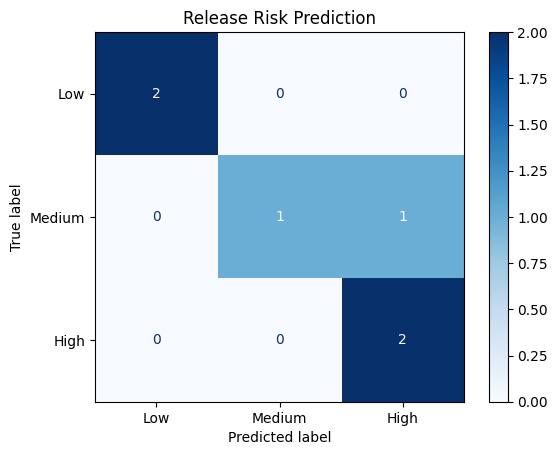

In [101]:
# ==========================================================
# CONFUSION MATRIX
# ==========================================================

cm = confusion_matrix(

    y_test,

    predictions

)

disp = ConfusionMatrixDisplay(

    confusion_matrix=cm,

    display_labels=[

        "Low",

        "Medium",

        "High"

    ]

)

disp.plot(

    cmap="Blues"

)

plt.title(

    "Release Risk Prediction"

)

plt.show()

In [102]:
# ==========================================================
# SAVE MODEL
# ==========================================================

joblib.dump(

    best_model,

    "best_release_svm_model.pkl"

)

joblib.dump(

    X.columns.tolist(),

    "release_features.pkl"

)

print("Release Risk Model Saved Successfully")

Release Risk Model Saved Successfully


In [103]:
# ==========================================================
# VERIFY MODEL
# ==========================================================

loaded_model = joblib.load(

    "best_release_svm_model.pkl"

)

print(type(loaded_model))

print("\nPipeline Steps")

print(loaded_model)

<class 'sklearn.pipeline.Pipeline'>

Pipeline Steps
Pipeline(steps=[('scaler', StandardScaler()),
                ('svm',
                 LinearSVC(C=0.01, class_weight='balanced', max_iter=10000,
                           random_state=42))])


# **PART 5B – Release Risk Prediction**

In [319]:
# ==========================================================
# PART 6
# RELEASE RISK PREDICTION
# ==========================================================

import pandas as pd
import joblib

In [320]:
# ==========================================================
# LOAD TRAINED MODEL
# ==========================================================

release_model = joblib.load(
    "best_release_svm_model.pkl"
)

release_features = joblib.load(
    "release_features.pkl"
)

print(type(release_model))

print("Release Risk Model Loaded Successfully")


<class 'sklearn.pipeline.Pipeline'>
Release Risk Model Loaded Successfully


In [321]:
# ==========================================================
# LOAD RELEASE DATASET
# ==========================================================

release_df = pd.read_csv(
    "generated_release_metrics.csv"
)

print(release_df.shape)

display(release_df.head())


(30, 35)


,release_id,release_size,release_complexity,microservices,team_experience,developer_experience,automation_percentage,code_coverage,pass_rate,defect_density,technical_debt,security_findings,failed_tests,deployment_duration,rollback_count,production_incidents,hotfix_count,requirement_volatility,integration_complexity,environment_stability,quality_index,deployment_efficiency,risk_density,incident_ratio,test_effectiveness,automation_score,technical_debt_index,stability_score,application,release_type,deployment_window,environment,risk_score,release_risk,release_risk_encoded
0,REL-001,Large,4,33,12,8,70,78,68.40,0.0,15,7,0,136,3,7,2,0.06,2,0.88,95.67,60.03,0.89,0.25,85.18,60.27,6.04,80.47,Payments,Patch,Night,UAT,41.27,High,2
1,REL-002,Large,3,7,6,3,56,80,80.32,0.0,22,3,0,108,3,5,1,0.20,5,0.69,69.16,86.65,0.59,0.33,70.72,74.86,13.20,89.46,Payments,Minor,Weekend,Pre-Production,33.54,Medium,1
2,REL-003,Medium,10,38,11,4,63,90,96.34,0.0,12,6,0,59,4,7,4,0.16,5,0.83,96.68,83.67,0.32,0.12,70.45,60.59,24.05,75.40,Loans,Patch,Weekend,Pre-Production,30.18,Medium,1
3,REL-004,Large,1,9,11,7,90,87,94.35,0.0,12,11,0,52,5,7,4,0.34,8,0.71,81.33,74.93,0.88,0.34,88.82,68.97,16.52,61.58,Payments,Minor,Weekend,Pre-Production,47.16,High,2
4,REL-005,Large,7,36,5,5,72,74,90.69,0.0,17,6,0,105,3,1,1,0.37,9,0.64,77.35,68.52,0.43,0.35,75.70,64.64,21.03,95.37,Retail Banking,Major,Business Hours,UAT,26.56,Low,0


In [322]:
# ==========================================================
# PREPARE FEATURES
# ==========================================================

drop_columns = [

    "release_id",

    "release_risk",

    "release_risk_encoded"

]

X = release_df.drop(
    columns=drop_columns,
    errors="ignore"
)

X = pd.get_dummies(
    X,
    drop_first=True
)

print("Encoded Shape :", X.shape)

Encoded Shape : (30, 39)


In [323]:
# ==========================================================
# ALIGN FEATURES
# ==========================================================

missing = sorted(
    set(release_features) - set(X.columns)
)

extra = sorted(
    set(X.columns) - set(release_features)
)

print("Missing Features :", missing)

print("Extra Features :", extra)

X = X.reindex(
    columns=release_features,
    fill_value=0
)

print("Final Shape :", X.shape)

Missing Features : []
Extra Features : []
Final Shape : (30, 39)


In [324]:
# ==========================================================
# PREDICT RELEASE RISK
# ==========================================================

predictions = release_model.predict(X)

release_df["Predicted_Risk_Encoded"] = predictions

risk_map = {

    0: "Low",

    1: "Medium",

    2: "High"

}

release_df["Predicted_Risk"] = (

    release_df["Predicted_Risk_Encoded"]

    .map(risk_map)

)

print("Prediction Completed Successfully")

Prediction Completed Successfully


In [325]:
# ==========================================================
# AI RECOMMENDATION
# ==========================================================

def recommendation(risk):

    if risk == "High":

        return "Delay Release and Resolve Critical Issues"

    elif risk == "Medium":

        return "Additional Testing Required"

    else:

        return "Ready for Production"


release_df["AI_Recommendation"] = (

    release_df["Predicted_Risk"]

    .apply(recommendation)

)

In [326]:
from sklearn.metrics import confusion_matrix

comparison = pd.DataFrame({
    "Actual": release_df["release_risk"],
    "Predicted": release_df["Predicted_Risk"]
})

print(comparison.head(15))

print("\nPrediction Accuracy on Full Dataset")

accuracy = (
    comparison["Actual"] == comparison["Predicted"]
).mean()

print(f"{accuracy*100:.2f}%")

    Actual Predicted
0     High      High
1   Medium    Medium
2   Medium    Medium
3     High      High
4      Low       Low
5      Low       Low
6     High      High
7      Low       Low
8   Medium    Medium
9     High      High
10  Medium    Medium
11  Medium    Medium
12  Medium    Medium
13  Medium      High
14    High      High

Prediction Accuracy on Full Dataset
96.67%


In [327]:
# ==========================================================
# RELEASE DASHBOARD
# ==========================================================

print("=" * 70)

print("RELEASE RISK DISTRIBUTION")

print("=" * 70)

print(
    release_df["Predicted_Risk"]
    .value_counts()
)

display(

    release_df[
        [
            "release_id",
            "application",
            "release_type",
            "risk_score",
            "release_risk",
            "Predicted_Risk",
            "AI_Recommendation"
        ]
    ]

)


RELEASE RISK DISTRIBUTION
Predicted_Risk
High      10
Medium    10
Low       10
Name: count, dtype: int64


,release_id,application,release_type,risk_score,release_risk,Predicted_Risk,AI_Recommendation
0,REL-001,Payments,Patch,41.27,High,High,Delay Release and Resolve Critical Issues
1,REL-002,Payments,Minor,33.54,Medium,Medium,Additional Testing Required
2,REL-003,Loans,Patch,30.18,Medium,Medium,Additional Testing Required
3,REL-004,Payments,Minor,47.16,High,High,Delay Release and Resolve Critical Issues
4,REL-005,Retail Banking,Major,26.56,Low,Low,Ready for Production
5,REL-006,Retail Banking,Minor,25.13,Low,Low,Ready for Production
6,REL-007,Treasury,Patch,38.62,High,High,Delay Release and Resolve Critical Issues
7,REL-008,Treasury,Major,26.30,Low,Low,Ready for Production
8,REL-009,Cards,Major,33.54,Medium,Medium,Additional Testing Required
9,REL-010,Retail Banking,Major,38.35,High,High,Delay Release and Resolve Critical Issues


In [328]:
# ==========================================================
# SAVE FINAL REPORT
# ==========================================================

release_df.to_csv(

    "final_ai_test_analytics_report.csv",

    index=False

)

print("=" * 70)

print("PIPELINE COMPLETED SUCCESSFULLY")

print("=" * 70)

print("Output Saved : final_ai_test_analytics_report.csv")

PIPELINE COMPLETED SUCCESSFULLY
Output Saved : final_ai_test_analytics_report.csv


# **Part 6A : Release Metrics dataset creation from Jira defects**

In [223]:
# ==========================================================
# PART 6A - CELL 1
# LOAD PREDICTED JIRA DATASET
# ==========================================================

import pandas as pd
import numpy as np
import random
from datetime import datetime, timedelta

# ----------------------------------------------------------
# Random Seed
# ----------------------------------------------------------

random.seed(42)
np.random.seed(42)

# ----------------------------------------------------------
# Load Predicted JIRA Dataset
# ----------------------------------------------------------

jira_df = pd.read_csv("predicted_jira_dataset.csv")

print("="*70)
print("PREDICTED JIRA DATASET LOADED")
print("="*70)

print("Rows :", jira_df.shape[0])
print("Columns :", jira_df.shape[1])

print("\nColumn Names\n")

for col in jira_df.columns:
    print(col)

print("\nFirst Five Records\n")

display(jira_df.head())

print("\nPredicted Severity Distribution\n")

display(
    jira_df["Predicted_Severity"].value_counts()
)

print("\nPercentage Distribution\n")

display(
    round(
        jira_df["Predicted_Severity"].value_counts(normalize=True)*100,
        2
    )
)

PREDICTED JIRA DATASET LOADED
Rows : 2278
Columns : 29

Column Names

bug_id
module
status
reopened_count
customer_impact
resolution_time_hours
root_cause
environment
resolution_team
affected_services
affected_users
created_date
resolved_date
priority
severity
severity_encoded
reopened_flag
frequent_reopen
sla_violation
resolution_category
log_users
service_density
resolution_efficiency
module_complexity
root_cause_risk
environment_risk
team_score
customer_impact_score
Predicted_Severity

First Five Records



,bug_id,module,status,reopened_count,customer_impact,resolution_time_hours,root_cause,environment,resolution_team,affected_services,affected_users,created_date,resolved_date,priority,severity,severity_encoded,reopened_flag,frequent_reopen,sla_violation,resolution_category,log_users,service_density,resolution_efficiency,module_complexity,root_cause_risk,environment_risk,team_score,customer_impact_score,Predicted_Severity
0,BUG00001,Payments,In Progress,0,Low,4,UI,PROD,Frontend,6,1748,2026-07-27 18:51:22.668246,2026-07-27 22:51:22.668246,Medium,Low,0,0,0,0,Fast,7.466799,6.000000,349.600000,5,1,NaN,3,1,Critical
1,BUG00002,Transfers,Open,2,Medium,20,API,SIT,QA,1,744,2026-07-31 18:51:22.668246,2026-08-01 14:51:22.668246,High,Low,0,1,1,0,Fast,6.613384,0.333333,35.428571,5,3,NaN,2,2,Medium
2,BUG00003,Loans,Open,1,Medium,61,Configuration,DEV,Frontend,2,4536,2026-07-10 18:51:22.668246,2026-07-13 07:51:22.668246,High,Low,0,1,0,1,Medium,8.420021,1.000000,73.161290,5,2,NaN,3,2,High
3,BUG00004,Transfers,In Progress,0,Low,62,UI,PROD,Database,2,6931,2026-07-10 18:51:22.668246,2026-07-13 08:51:22.668246,Medium,Low,0,0,0,1,Medium,8.843904,2.000000,110.015873,5,1,NaN,5,1,High
4,BUG00005,Payments,Resolved,0,High,35,Infrastructure,UAT,DevOps,7,5341,2026-07-24 18:51:22.668246,2026-07-26 05:51:22.668246,Highest,Low,0,0,0,0,Medium,8.583355,7.000000,148.361111,5,4,3.0,4,3,Critical



Predicted Severity Distribution



,count
Predicted_Severity,
High,1060
Critical,657
Medium,547
Low,14



Percentage Distribution



,proportion
Predicted_Severity,
High,46.53
Critical,28.84
Medium,24.01
Low,0.61


In [224]:
# ==========================================================
# PART 6A - CELL 2
# GENERATE RELEASE METRICS DATASET
# (Training Distribution + JIRA Influence)
# ==========================================================

NUM_RELEASES = 300

release_records = []

release_types = [
    "Major",
    "Minor",
    "Patch",
    "Hotfix"
]

applications = [
    "Internet Banking",
    "Mobile Banking",
    "Payments",
    "Cards",
    "Loans",
    "CRM",
    "Treasury",
    "Authentication"
]

deployment_windows = [
    "Business Hours",
    "Night",
    "Weekend"
]

environments = [
    "QA",
    "UAT",
    "Production"
]

release_start = datetime(2025,1,1)

for i in range(NUM_RELEASES):

    # --------------------------------------------------
    # Sample JIRA Defects
    # --------------------------------------------------

    sample_size = np.random.randint(10,20)

    sample = jira_df.sample(
        n=sample_size,
        replace=True,
        random_state=i
    )

    critical = (sample["Predicted_Severity"]=="Critical").sum()

    high = (sample["Predicted_Severity"]=="High").sum()

    medium = (sample["Predicted_Severity"]=="Medium").sum()

    low = (sample["Predicted_Severity"]=="Low").sum()

    # Small influence only

    jira_factor = (

        critical*4 +

        high*2 +

        medium +

        low*0.25

    ) / sample_size

    # --------------------------------------------------
    # Release Details
    # --------------------------------------------------

    release_id = f"REL{i+1:05d}"

    application = random.choice(applications)

    release_type = random.choices(

        release_types,

        weights=[20,35,30,15],

        k=1

    )[0]

    deployment_window = random.choices(

        deployment_windows,

        weights=[20,50,30],

        k=1

    )[0]

    environment = random.choices(

        environments,

        weights=[30,30,40],

        k=1

    )[0]

    # --------------------------------------------------
    # Release Size (IDENTICAL TO TRAINING)
    # --------------------------------------------------

    if release_type=="Major":

        release_size=max(
            120,
            int(np.random.normal(350,80))
        )

        release_complexity=random.randint(7,10)

        microservices=random.randint(12,25)

    elif release_type=="Minor":

        release_size=max(
            60,
            int(np.random.normal(180,45))
        )

        release_complexity=random.randint(4,8)

        microservices=random.randint(8,18)

    elif release_type=="Patch":

        release_size=max(
            20,
            int(np.random.normal(70,20))
        )

        release_complexity=random.randint(2,5)

        microservices=random.randint(3,10)

    else:

        release_size=max(
            5,
            int(np.random.normal(30,10))
        )

        release_complexity=random.randint(1,3)

        microservices=random.randint(1,5)

    # --------------------------------------------------
    # Engineering Metrics
    # --------------------------------------------------

    team_experience=max(
        1,
        int(np.random.normal(6,2))
    )

    developer_experience=max(
        1,
        int(np.random.normal(5,2))
    )

    automation_percentage=np.clip(
        np.random.normal(78,12),
        40,
        100
    )

    code_coverage=np.clip(
        np.random.normal(82,8),
        50,
        98
    )

    pass_rate=np.clip(

        np.random.normal(

            90 - jira_factor*0.20,

            6

        ),

        60,

        100

    )

    defect_density=max(

        0.2,

        np.random.normal(

            4.5 + jira_factor*0.05,

            2

        )

    )

    technical_debt=max(

        1,

        int(

            np.random.normal(

                18 + jira_factor*0.40,

                8

            )

        )

    )

    security_findings=min(

        np.random.poisson(

            2 + jira_factor*0.03

        ),

        5

    )

    failed_tests=max(

        0,

        int(

            np.random.normal(

                45 + jira_factor*0.75,

                18

            )

        )

    )

    deployment_duration=max(

        20,

        int(

            np.random.normal(

                90 + jira_factor*0.30,

                30

            )

        )

    )

    rollback_count=min(

        np.random.poisson(

            1 + jira_factor*0.02

        ),

        4

    )

    production_incidents=min(

        np.random.poisson(

            1 + jira_factor*0.02

        ),

        5

    )

    hotfix_count=min(

        np.random.poisson(

            2 + jira_factor*0.02

        ),

        6

    )

    requirement_volatility=random.randint(1,10)

    integration_complexity=random.randint(1,10)

    environment_stability=random.randint(1,10)

    release_date=release_start+timedelta(

        days=random.randint(0,365)

    )

    release_records.append([

        release_id,

        application,

        release_type,

        deployment_window,

        environment,

        release_size,

        release_complexity,

        microservices,

        team_experience,

        developer_experience,

        automation_percentage,

        code_coverage,

        pass_rate,

        defect_density,

        technical_debt,

        security_findings,

        failed_tests,

        deployment_duration,

        rollback_count,

        production_incidents,

        hotfix_count,

        requirement_volatility,

        integration_complexity,

        environment_stability,

        release_date

    ])

print("="*70)
print("RELEASE METRICS GENERATED")
print("="*70)

print("Total Releases :", len(release_records))

RELEASE METRICS GENERATED
Total Releases : 300


In [225]:
# ==========================================================
# PART 6A - CELL 3
# DATAFRAME CREATION + FEATURE ENGINEERING
# ==========================================================

release_df = pd.DataFrame(

    release_records,

    columns=[

        "release_id",

        "application",

        "release_type",

        "deployment_window",

        "environment",

        "release_size",

        "release_complexity",

        "microservices",

        "team_experience",

        "developer_experience",

        "automation_percentage",

        "code_coverage",

        "pass_rate",

        "defect_density",

        "technical_debt",

        "security_findings",

        "failed_tests",

        "deployment_duration",

        "rollback_count",

        "production_incidents",

        "hotfix_count",

        "requirement_volatility",

        "integration_complexity",

        "environment_stability",

        "release_date"

    ]

)

print("="*70)
print("RELEASE DATAFRAME CREATED")
print("="*70)

print("Dataset Shape :", release_df.shape)

display(release_df.head())

# ==========================================================
# FEATURE ENGINEERING
# (Exactly Same As Training Notebook)
# ==========================================================

# ----------------------------------------------------------
# Quality Index
# ----------------------------------------------------------

release_df["quality_index"] = (

    release_df["code_coverage"]

    *

    release_df["pass_rate"]

) / (

    release_df["defect_density"] + 1

)

# ----------------------------------------------------------
# Deployment Efficiency
# ----------------------------------------------------------

release_df["deployment_efficiency"] = (

    release_df["automation_percentage"]

) / (

    release_df["deployment_duration"]

)

# ----------------------------------------------------------
# Risk Density
# ----------------------------------------------------------

release_df["risk_density"] = (

    release_df["defect_density"]

    *

    release_df["release_complexity"]

) / (

    release_df["team_experience"] + 1

)

# ----------------------------------------------------------
# Incident Ratio
# ----------------------------------------------------------

release_df["incident_ratio"] = (

    release_df["production_incidents"]

) / (

    release_df["release_size"] + 1

)

# ----------------------------------------------------------
# Test Effectiveness
# ----------------------------------------------------------

release_df["test_effectiveness"] = (

    release_df["pass_rate"]

) / (

    release_df["failed_tests"] + 1

)

# ----------------------------------------------------------
# Automation Score
# ----------------------------------------------------------

release_df["automation_score"] = (

    release_df["automation_percentage"]

    *

    release_df["code_coverage"]

) / 100

# ----------------------------------------------------------
# Technical Debt Index
# ----------------------------------------------------------

release_df["technical_debt_index"] = (

    release_df["technical_debt"]

    *

    release_df["requirement_volatility"]

)

# ----------------------------------------------------------
# Stability Score
# ----------------------------------------------------------

release_df["stability_score"] = (

    release_df["environment_stability"]

    *

    release_df["team_experience"]

)

print()

print("="*70)
print("FEATURE ENGINEERING COMPLETED")
print("="*70)

print("Final Dataset Shape :", release_df.shape)

print()

display(release_df.head())

print()

print("Columns After Feature Engineering")

print(release_df.columns.tolist())

RELEASE DATAFRAME CREATED
Dataset Shape : (300, 25)


,release_id,application,release_type,deployment_window,environment,release_size,release_complexity,microservices,team_experience,developer_experience,automation_percentage,code_coverage,pass_rate,defect_density,technical_debt,security_findings,failed_tests,deployment_duration,rollback_count,production_incidents,hotfix_count,requirement_volatility,integration_complexity,environment_stability,release_date
0,REL00001,Mobile Banking,Major,Night,QA,305,7,22,7,5,94.421401,74.665385,88.805117,0.590574,14,1,48,85,1,3,0,9,2,10,2025-08-05
1,REL00002,Internet Banking,Major,Night,UAT,329,7,20,5,2,95.843771,81.804359,91.691203,5.444549,25,1,48,110,1,0,2,4,9,7,2025-04-23
2,REL00003,Authentication,Patch,Weekend,QA,86,3,9,3,5,54.483959,71.374512,90.722344,6.091639,20,0,28,43,0,1,2,6,5,3,2025-04-21
3,REL00004,CRM,Major,Night,UAT,346,9,21,5,1,68.452428,89.444675,93.806604,5.961881,19,4,72,56,2,1,4,5,1,8,2025-10-02
4,REL00005,Mobile Banking,Hotfix,Night,UAT,23,3,5,6,2,74.630325,81.521462,95.367043,8.188562,23,1,20,96,3,1,0,6,10,4,2025-12-27



FEATURE ENGINEERING COMPLETED
Final Dataset Shape : (300, 33)



,release_id,application,release_type,deployment_window,environment,release_size,release_complexity,microservices,team_experience,developer_experience,automation_percentage,code_coverage,pass_rate,defect_density,technical_debt,security_findings,failed_tests,deployment_duration,rollback_count,production_incidents,hotfix_count,requirement_volatility,integration_complexity,environment_stability,release_date,quality_index,deployment_efficiency,risk_density,incident_ratio,test_effectiveness,automation_score,technical_debt_index,stability_score
0,REL00001,Mobile Banking,Major,Night,QA,305,7,22,7,5,94.421401,74.665385,88.805117,0.590574,14,1,48,85,1,3,0,9,2,10,2025-08-05,4168.726100,1.110840,0.516752,0.009804,1.812349,70.500103,126,70
1,REL00002,Internet Banking,Major,Night,UAT,329,7,20,5,2,95.843771,81.804359,91.691203,5.444549,25,1,48,110,1,0,2,4,9,7,2025-04-23,1163.889135,0.871307,6.351973,0.000000,1.871249,78.404383,100,35
2,REL00003,Authentication,Patch,Weekend,QA,86,3,9,3,5,54.483959,71.374512,90.722344,6.091639,20,0,28,43,0,1,2,6,5,3,2025-04-21,913.084119,1.267069,4.568729,0.011494,3.128357,38.887659,120,9
3,REL00004,CRM,Major,Night,UAT,346,9,21,5,1,68.452428,89.444675,93.806604,5.961881,19,4,72,56,2,1,4,5,1,8,2025-10-02,1205.206157,1.222365,8.942821,0.002882,1.285022,61.227052,95,40
4,REL00005,Mobile Banking,Hotfix,Night,UAT,23,3,5,6,2,74.630325,81.521462,95.367043,8.188562,23,1,20,96,3,1,0,6,10,4,2025-12-27,846.102034,0.777399,3.509384,0.041667,4.541288,60.839732,138,24



Columns After Feature Engineering
['release_id', 'application', 'release_type', 'deployment_window', 'environment', 'release_size', 'release_complexity', 'microservices', 'team_experience', 'developer_experience', 'automation_percentage', 'code_coverage', 'pass_rate', 'defect_density', 'technical_debt', 'security_findings', 'failed_tests', 'deployment_duration', 'rollback_count', 'production_incidents', 'hotfix_count', 'requirement_volatility', 'integration_complexity', 'environment_stability', 'release_date', 'quality_index', 'deployment_efficiency', 'risk_density', 'incident_ratio', 'test_effectiveness', 'automation_score', 'technical_debt_index', 'stability_score']


In [226]:
release_df[
    [
        "failed_tests",
        "defect_density",
        "rollback_count",
        "production_incidents",
        "pass_rate"
    ]
].describe()

,failed_tests,defect_density,rollback_count,production_incidents,pass_rate
count,300.000000,300.000000,300.000000,300.000000,300.000000
mean,47.070000,4.795184,1.056667,1.036667,89.516323
std,18.667799,1.995279,1.106437,1.041925,5.786681
min,0.000000,0.200000,0.000000,0.000000,71.991002
25%,36.000000,3.240943,0.000000,0.000000,85.387688
50%,48.000000,4.894820,1.000000,1.000000,89.844263
75%,61.000000,6.101358,2.000000,2.000000,93.889004
max,97.000000,9.946845,4.000000,5.000000,100.000000


In [228]:
# ==========================================================
# PART 6A - CELL 4
# RISK SCORE + TARGET GENERATION
# (Exactly Same As Training Notebook)
# ==========================================================

# ----------------------------------------------------------
# Probabilistic Risk Score
# ----------------------------------------------------------

risk_score = (

      release_df["defect_density"] * 14

    + release_df["failed_tests"] * 0.35

    + release_df["rollback_count"] * 15

    + release_df["production_incidents"] * 18

    + release_df["security_findings"] * 7

    + release_df["technical_debt"] * 0.8

    + release_df["release_complexity"] * 3

    + release_df["integration_complexity"] * 2

    + release_df["requirement_volatility"] * 2

    - release_df["code_coverage"] * 0.60

    - release_df["automation_percentage"] * 0.40

    - release_df["team_experience"] * 2

    - release_df["developer_experience"] * 1.5

)

# ----------------------------------------------------------
# Add Business Noise
# ----------------------------------------------------------

risk_score = (

    risk_score +

    np.random.normal(

        loc=0,

        scale=10,

        size=len(release_df)

    )

)

release_df["risk_score"] = risk_score.round(2)
# ==========================================================
# Normalize Risk Score
# ==========================================================

release_df["risk_score"] = (
    (release_df["risk_score"] - release_df["risk_score"].mean())
    / release_df["risk_score"].std()
)

release_df["risk_score"] = (
    release_df["risk_score"] * 25 + 75
)

release_df["risk_score"] = release_df["risk_score"].round(2)

# ==========================================================
# CREATE TARGET VARIABLE
# ==========================================================

conditions = [

    release_df["risk_score"] < 55,

    (release_df["risk_score"] >= 55) &
    (release_df["risk_score"] < 95),

    release_df["risk_score"] >= 95

]

labels = [

    "Low",

    "Medium",

    "High"

]

release_df["release_risk"] = np.select(

    conditions,

    labels,

    default="Medium"

)

risk_encoding = {

    "Low":0,

    "Medium":1,

    "High":2

}

release_df["release_risk_encoded"] = (

    release_df["release_risk"]

    .map(risk_encoding)

)

# ==========================================================
# DISPLAY RESULTS
# ==========================================================

print("="*70)
print("RISK SCORE GENERATED")
print("="*70)

print()

print("Risk Score Statistics")

display(
    release_df["risk_score"].describe()
)

print()

print("Release Risk Distribution")

display(
    release_df["release_risk"].value_counts()
)

print()

display(
    round(
        release_df["release_risk"].value_counts(normalize=True)*100,
        2
    )
)

print()

display(

    release_df[
        [
            "risk_score",
            "release_risk",
            "release_risk_encoded"
        ]
    ].head()

)

RISK SCORE GENERATED

Risk Score Statistics


,risk_score
count,300.000000
mean,75.000167
std,25.000062
min,6.530000
25%,57.705000
50%,75.100000
75%,90.322500
max,145.750000



Release Risk Distribution


,count
release_risk,
Medium,177
Low,65
High,58


,proportion
release_risk,
Medium,59.00
Low,21.67
High,19.33


,risk_score,release_risk,release_risk_encoded
0,52.22,Low,0
1,77.77,Medium,1
2,83.81,Medium,1
3,109.95,High,2
4,115.77,High,2


In [229]:
# ==========================================================
# CREATE TARGET VARIABLE
# (MATCH TRAINING DISTRIBUTION)
# ==========================================================

low_threshold = release_df["risk_score"].quantile(0.2875)
high_threshold = release_df["risk_score"].quantile(0.6488)

print("="*60)
print("Risk Score Thresholds")
print("="*60)

print(f"Low Threshold  : {low_threshold:.2f}")
print(f"High Threshold : {high_threshold:.2f}")

conditions = [

    release_df["risk_score"] < low_threshold,

    (release_df["risk_score"] >= low_threshold) &
    (release_df["risk_score"] < high_threshold),

    release_df["risk_score"] >= high_threshold

]

labels = [

    "Low",

    "Medium",

    "High"

]

release_df["release_risk"] = np.select(
    conditions,
    labels,
    default="Medium"
)

risk_encoding = {

    "Low":0,

    "Medium":1,

    "High":2

}

release_df["release_risk_encoded"] = (
    release_df["release_risk"]
    .map(risk_encoding)
)

print()
print("Release Risk Distribution")
print(release_df["release_risk"].value_counts())

Risk Score Thresholds
Low Threshold  : 61.10
High Threshold : 83.80

Release Risk Distribution
release_risk
Medium    108
High      106
Low        86
Name: count, dtype: int64


In [230]:
print(release_df["risk_score"].describe())
print(release_df["release_risk"].value_counts())

count    300.000000
mean      75.000167
std       25.000062
min        6.530000
25%       57.705000
50%       75.100000
75%       90.322500
max      145.750000
Name: risk_score, dtype: float64
release_risk
Medium    108
High      106
Low        86
Name: count, dtype: int64


# **Part 6B: Predict Release Metric using Xgboost**

In [231]:
# ==========================================================
# PART 6A
# LOAD TRAINED XGBOOST RELEASE RISK MODEL
# ==========================================================

import joblib
import pandas as pd
import numpy as np

print("="*60)
print("LOADING TRAINED RELEASE RISK XGBOOST MODEL")
print("="*60)

# ----------------------------------------------------------
# Load Trained Model
# ----------------------------------------------------------

release_model = joblib.load(
    MODEL_PATH + "best_release_xgb_model.pkl"
)

# ----------------------------------------------------------
# Load Feature List
# ----------------------------------------------------------

release_feature_columns = joblib.load(
    MODEL_PATH + "release_xgb_features.pkl"
)

print("✓ Release Risk XGBoost Model Loaded")

print("✓ Feature List Loaded")

print()

print("Expected Features :", len(release_feature_columns))

print()

print("First 10 Features")

print(release_feature_columns[:10])

LOADING TRAINED RELEASE RISK XGBOOST MODEL
✓ Release Risk XGBoost Model Loaded
✓ Feature List Loaded

Expected Features : 41

First 10 Features
Index(['release_size', 'release_complexity', 'microservices', 'team_experience', 'developer_experience', 'automation_percentage', 'code_coverage', 'pass_rate', 'defect_density', 'technical_debt'], dtype='object')


In [232]:
# ==========================================================
# PART 6A - CELL 2
# PREPARE FEATURES
# ==========================================================

print("="*60)
print("PREPARING FEATURES")
print("="*60)

# ----------------------------------------------------------
# Target Column
# ----------------------------------------------------------

target = "release_risk_encoded"

# ----------------------------------------------------------
# Drop Columns
# (Same as Training)
# ----------------------------------------------------------

drop_columns = [

    "release_id",

    "release_date",

    "release_risk",

    "release_risk_encoded",

    "risk_score"

]

X = release_df.drop(columns=drop_columns)

y = release_df[target]

# ----------------------------------------------------------
# One-Hot Encoding
# ----------------------------------------------------------

categorical_columns = X.select_dtypes(include="object").columns

X = pd.get_dummies(

    X,

    columns=categorical_columns,

    drop_first=True

)

# ----------------------------------------------------------
# Align Features
# ----------------------------------------------------------

X = X.reindex(

    columns=release_feature_columns,

    fill_value=0

)

print()

print("Feature Matrix Shape :", X.shape)

print("Expected Features    :", len(release_feature_columns))

print()

print("Feature Alignment Successful")

display(X.head())

PREPARING FEATURES

Feature Matrix Shape : (300, 41)
Expected Features    : 41

Feature Alignment Successful


,release_size,release_complexity,microservices,team_experience,developer_experience,automation_percentage,code_coverage,pass_rate,defect_density,technical_debt,security_findings,failed_tests,deployment_duration,rollback_count,production_incidents,hotfix_count,requirement_volatility,integration_complexity,environment_stability,quality_index,deployment_efficiency,risk_density,incident_ratio,test_effectiveness,automation_score,technical_debt_index,stability_score,application_CRM,application_Cards,application_Internet Banking,application_Loans,application_Mobile Banking,application_Payments,application_Treasury,release_type_Major,release_type_Minor,release_type_Patch,deployment_window_Night,deployment_window_Weekend,environment_QA,environment_UAT
0,305,7,22,7,5,94.421401,74.665385,88.805117,0.590574,14,1,48,85,1,3,0,9,2,10,4168.726100,1.110840,0.516752,0.009804,1.812349,70.500103,126,70,False,False,False,False,True,False,False,True,False,False,True,False,True,False
1,329,7,20,5,2,95.843771,81.804359,91.691203,5.444549,25,1,48,110,1,0,2,4,9,7,1163.889135,0.871307,6.351973,0.000000,1.871249,78.404383,100,35,False,False,True,False,False,False,False,True,False,False,True,False,False,True
2,86,3,9,3,5,54.483959,71.374512,90.722344,6.091639,20,0,28,43,0,1,2,6,5,3,913.084119,1.267069,4.568729,0.011494,3.128357,38.887659,120,9,False,False,False,False,False,False,False,False,False,True,False,True,True,False
3,346,9,21,5,1,68.452428,89.444675,93.806604,5.961881,19,4,72,56,2,1,4,5,1,8,1205.206157,1.222365,8.942821,0.002882,1.285022,61.227052,95,40,True,False,False,False,False,False,False,True,False,False,True,False,False,True
4,23,3,5,6,2,74.630325,81.521462,95.367043,8.188562,23,1,20,96,3,1,0,6,10,4,846.102034,0.777399,3.509384,0.041667,4.541288,60.839732,138,24,False,False,False,False,True,False,False,False,False,False,True,False,False,True


In [233]:
# ==========================================================
# PART 6A - CELL 3
# PREDICT RELEASE RISK USING XGBOOST
# ==========================================================

print("="*60)
print("PREDICTING RELEASE RISK")
print("="*60)

# ----------------------------------------------------------
# Predict Release Risk
# ----------------------------------------------------------

predictions = release_model.predict(X)

# ----------------------------------------------------------
# Store Encoded Predictions
# ----------------------------------------------------------

release_df["Predicted_Risk_Encoded"] = predictions

# ----------------------------------------------------------
# Convert Encoded Labels
# ----------------------------------------------------------

risk_map = {

    0: "Low",

    1: "Medium",

    2: "High"

}

release_df["Predicted_Release_Risk"] = (

    release_df["Predicted_Risk_Encoded"]

    .map(risk_map)

)

print()

print("Prediction Completed Successfully")

print()

display(

    release_df[
        [
            "release_risk",
            "Predicted_Release_Risk"
        ]
    ].head()

)

print()

print("="*60)
print("PREDICTION DISTRIBUTION")
print("="*60)

display(

    release_df["Predicted_Release_Risk"]

    .value_counts()

)

print()

display(

    round(

        release_df["Predicted_Release_Risk"]

        .value_counts(normalize=True) * 100,

        2

    )

)

PREDICTING RELEASE RISK

Prediction Completed Successfully



,release_risk,Predicted_Release_Risk
0,Low,Medium
1,Medium,Medium
2,High,Medium
3,High,High
4,High,High



PREDICTION DISTRIBUTION


,count
Predicted_Release_Risk,
High,126
Medium,104
Low,70


,proportion
Predicted_Release_Risk,
High,42.00
Medium,34.67
Low,23.33


In [234]:
# ==========================================================
# PART 6A - CELL 4
# EVALUATE RELEASE RISK PREDICTION
# ==========================================================

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

print("="*60)
print("MODEL EVALUATION")
print("="*60)

# ----------------------------------------------------------
# Accuracy
# ----------------------------------------------------------

accuracy = accuracy_score(

    release_df["release_risk_encoded"],

    release_df["Predicted_Risk_Encoded"]

)

print(f"Accuracy : {accuracy:.2%}")

print()

# ----------------------------------------------------------
# Confusion Matrix
# ----------------------------------------------------------

print("="*60)
print("CONFUSION MATRIX")
print("="*60)

cm = confusion_matrix(

    release_df["release_risk_encoded"],

    release_df["Predicted_Risk_Encoded"]

)

cm_df = pd.DataFrame(

    cm,

    index=[

        "Actual Low",

        "Actual Medium",

        "Actual High"

    ],

    columns=[

        "Predicted Low",

        "Predicted Medium",

        "Predicted High"

    ]

)

display(cm_df)

print()

# ----------------------------------------------------------
# Classification Report
# ----------------------------------------------------------

print("="*60)
print("CLASSIFICATION REPORT")
print("="*60)

print(

    classification_report(

        release_df["release_risk_encoded"],

        release_df["Predicted_Risk_Encoded"],

        target_names=[

            "Low",

            "Medium",

            "High"

        ]

    )

)

MODEL EVALUATION
Accuracy : 77.33%

CONFUSION MATRIX


,Predicted Low,Predicted Medium,Predicted High
Actual Low,62,24,0
Actual Medium,8,72,28
Actual High,0,8,98



CLASSIFICATION REPORT
              precision    recall  f1-score   support

         Low       0.89      0.72      0.79        86
      Medium       0.69      0.67      0.68       108
        High       0.78      0.92      0.84       106

    accuracy                           0.77       300
   macro avg       0.79      0.77      0.77       300
weighted avg       0.78      0.77      0.77       300



In [235]:
feature_cols = [

    "quality_index",
    "deployment_efficiency",
    "risk_density",
    "incident_ratio",
    "test_effectiveness",
    "automation_score",
    "technical_debt_index",
    "stability_score"

]

print(release_df[feature_cols].describe())

       quality_index  deployment_efficiency  risk_density  incident_ratio  test_effectiveness  automation_score  technical_debt_index  stability_score
count     300.000000             300.000000    300.000000      300.000000          300.000000        300.000000            300.000000       300.000000
mean     1507.842422               0.952099      4.056525        0.013778            3.506998         63.249894            107.320000        31.166667
std       899.067959               0.407180      3.469343        0.024887           10.180681         11.539167             68.150122        19.963651
min       536.068151               0.389569      0.080000        0.000000            0.877939         34.724436              2.000000         2.000000
25%      1009.226686               0.684487      1.661224        0.000000            1.435406         55.364411             55.750000        14.750000
50%      1225.634522               0.840777      3.216926        0.005683            1.863242 

In [241]:
# ==========================================================
# AI RECOMMENDATION
# ==========================================================

def recommendation(risk):

    if risk == "High":

        return "Delay Release and Resolve Critical Issues"

    elif risk == "Medium":

        return "Additional Testing Required"

    else:

        return "Ready for Production"


release_df["AI_Recommendation"] = (

    release_df["Predicted_Release_Risk"]

    .apply(recommendation)

)

In [243]:
from sklearn.metrics import confusion_matrix

comparison = pd.DataFrame({
    "Actual": release_df["release_risk"],
    "Predicted": release_df["Predicted_Release_Risk"]
})

print(comparison.head(15))

print("\nPrediction Accuracy on Full Dataset")

accuracy = (
    comparison["Actual"] == comparison["Predicted"]
).mean()

print(f"{accuracy*100:.2f}%")

    Actual Predicted
0      Low    Medium
1   Medium    Medium
2     High    Medium
3     High      High
4     High      High
5      Low       Low
6      Low       Low
7     High      High
8     High      High
9      Low       Low
10  Medium    Medium
11  Medium    Medium
12     Low       Low
13     Low       Low
14  Medium    Medium

Prediction Accuracy on Full Dataset
77.33%


In [246]:
# ==========================================================
# RELEASE DASHBOARD
# ==========================================================

print("=" * 70)

print("RELEASE RISK DISTRIBUTION")

print("=" * 70)

print(
    release_df["Predicted_Release_Risk"]
    .value_counts()
)

display(

    release_df[
        [
            "release_id",
            "application",
            "release_type",
            "risk_score",
            "release_risk",
            "Predicted_Release_Risk",
            "AI_Recommendation"
        ]
    ]

)


RELEASE RISK DISTRIBUTION
Predicted_Release_Risk
High      126
Medium    104
Low        70
Name: count, dtype: int64


,release_id,application,release_type,risk_score,release_risk,Predicted_Release_Risk,AI_Recommendation
0,REL00001,Mobile Banking,Major,52.22,Low,Medium,Additional Testing Required
1,REL00002,Internet Banking,Major,77.77,Medium,Medium,Additional Testing Required
2,REL00003,Authentication,Patch,83.81,High,Medium,Additional Testing Required
3,REL00004,CRM,Major,109.95,High,High,Delay Release and Resolve Critical Issues
4,REL00005,Mobile Banking,Hotfix,115.77,High,High,Delay Release and Resolve Critical Issues
...,...,...,...,...,...,...,...
295,REL00296,Cards,Patch,17.19,Low,Low,Ready for Production
296,REL00297,Mobile Banking,Minor,125.47,High,High,Delay Release and Resolve Critical Issues
297,REL00298,Payments,Patch,95.91,High,Medium,Additional Testing Required
298,REL00299,Internet Banking,Hotfix,55.18,Low,Low,Ready for Production


In [247]:
# ==========================================================
# SAVE FINAL REPORT
# ==========================================================

release_df.to_csv(

    "final_ai_test_analytics_report.csv",

    index=False

)

print("=" * 70)

print("PIPELINE COMPLETED SUCCESSFULLY")

print("=" * 70)

print("Output Saved : final_ai_test_analytics_report.csv")

PIPELINE COMPLETED SUCCESSFULLY
Output Saved : final_ai_test_analytics_report.csv


# **PART 7 – Executive AI Analytics Dashboard**

In [248]:
# ==========================================================
# PART 7
# EXECUTIVE AI ANALYTICS DASHBOARD
# ==========================================================

import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("ggplot")

In [249]:
# ==========================================================
# LOAD FINAL REPORT
# ==========================================================

dashboard_df = pd.read_csv("final_ai_test_analytics_report.csv")

print("Dashboard Dataset Loaded Successfully")

print(dashboard_df.shape)

display(dashboard_df.head())

Dashboard Dataset Loaded Successfully
(300, 39)


,release_id,application,release_type,deployment_window,environment,release_size,release_complexity,microservices,team_experience,developer_experience,automation_percentage,code_coverage,pass_rate,defect_density,technical_debt,security_findings,failed_tests,deployment_duration,rollback_count,production_incidents,hotfix_count,requirement_volatility,integration_complexity,environment_stability,release_date,quality_index,deployment_efficiency,risk_density,incident_ratio,test_effectiveness,automation_score,technical_debt_index,stability_score,risk_score,release_risk,release_risk_encoded,Predicted_Risk_Encoded,Predicted_Release_Risk,AI_Recommendation
0,REL00001,Mobile Banking,Major,Night,QA,305,7,22,7,5,94.421401,74.665385,88.805117,0.590574,14,1,48,85,1,3,0,9,2,10,2025-08-05,4168.726100,1.110840,0.516752,0.009804,1.812349,70.500103,126,70,52.22,Low,0,1,Medium,Additional Testing Required
1,REL00002,Internet Banking,Major,Night,UAT,329,7,20,5,2,95.843771,81.804359,91.691203,5.444549,25,1,48,110,1,0,2,4,9,7,2025-04-23,1163.889135,0.871307,6.351973,0.000000,1.871249,78.404383,100,35,77.77,Medium,1,1,Medium,Additional Testing Required
2,REL00003,Authentication,Patch,Weekend,QA,86,3,9,3,5,54.483959,71.374512,90.722344,6.091639,20,0,28,43,0,1,2,6,5,3,2025-04-21,913.084119,1.267069,4.568729,0.011494,3.128357,38.887659,120,9,83.81,High,2,1,Medium,Additional Testing Required
3,REL00004,CRM,Major,Night,UAT,346,9,21,5,1,68.452428,89.444675,93.806604,5.961881,19,4,72,56,2,1,4,5,1,8,2025-10-02,1205.206157,1.222365,8.942821,0.002882,1.285022,61.227052,95,40,109.95,High,2,2,High,Delay Release and Resolve Critical Issues
4,REL00005,Mobile Banking,Hotfix,Night,UAT,23,3,5,6,2,74.630325,81.521462,95.367043,8.188562,23,1,20,96,3,1,0,6,10,4,2025-12-27,846.102034,0.777399,3.509384,0.041667,4.541288,60.839732,138,24,115.77,High,2,2,High,Delay Release and Resolve Critical Issues


In [252]:
# ==========================================================
# EXECUTIVE KPI SUMMARY
# ==========================================================

total_releases = len(dashboard_df)

high = (dashboard_df["Predicted_Release_Risk"] == "High").sum()

medium = (dashboard_df["Predicted_Release_Risk"] == "Medium").sum()

low = (dashboard_df["Predicted_Release_Risk"] == "Low").sum()

avg_risk = dashboard_df["risk_score"].mean()

avg_pass = dashboard_df["pass_rate"].mean()

avg_coverage = dashboard_df["code_coverage"].mean()

print("="*70)
print("EXECUTIVE KPI DASHBOARD")
print("="*70)

print(f"Total Releases            : {total_releases}")
print(f"High Risk Releases        : {high}")
print(f"Medium Risk Releases      : {medium}")
print(f"Low Risk Releases         : {low}")

print("-"*70)

print(f"Average Risk Score        : {avg_risk:.2f}")
print(f"Average Pass Rate (%)     : {avg_pass:.2f}")
print(f"Average Code Coverage (%) : {avg_coverage:.2f}")

print("="*70)

EXECUTIVE KPI DASHBOARD
Total Releases            : 300
High Risk Releases        : 126
Medium Risk Releases      : 104
Low Risk Releases         : 70
----------------------------------------------------------------------
Average Risk Score        : 75.00
Average Pass Rate (%)     : 89.52
Average Code Coverage (%) : 81.57


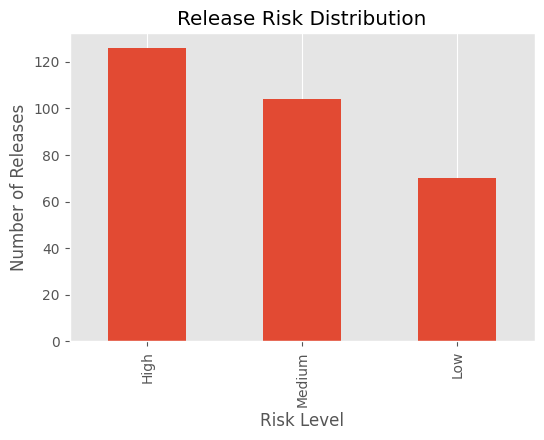

In [253]:
# ==========================================================
# RELEASE RISK DISTRIBUTION
# ==========================================================

risk_counts = dashboard_df["Predicted_Release_Risk"].value_counts()

plt.figure(figsize=(6,4))

risk_counts.plot(kind="bar")

plt.title("Release Risk Distribution")

plt.xlabel("Risk Level")

plt.ylabel("Number of Releases")

plt.grid(axis="y")

plt.show()

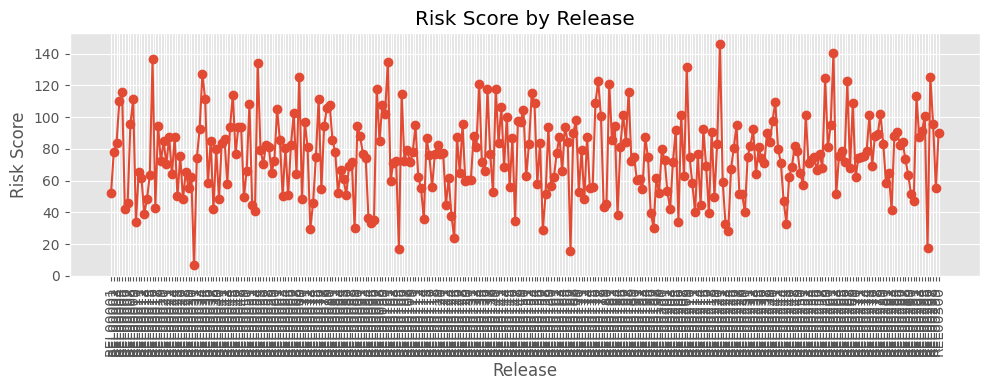

In [254]:
# ==========================================================
# RISK SCORE BY RELEASE
# ==========================================================

plt.figure(figsize=(10,4))

plt.plot(
    dashboard_df["release_id"],
    dashboard_df["risk_score"],
    marker="o"
)

plt.xticks(rotation=90)

plt.title("Risk Score by Release")

plt.ylabel("Risk Score")

plt.xlabel("Release")

plt.tight_layout()

plt.show()

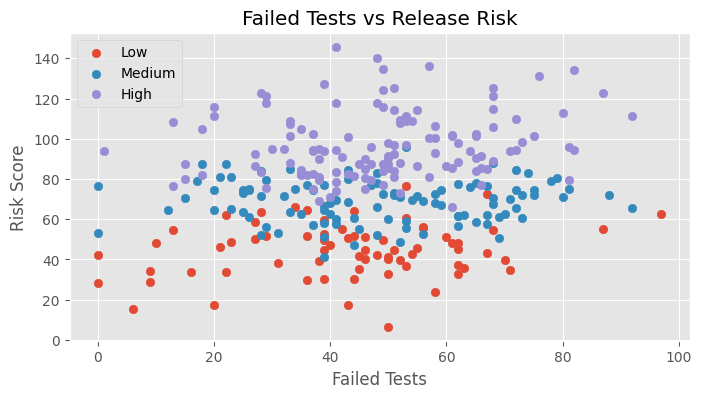

In [255]:
# ==========================================================
# FAILED TESTS VS RELEASE RISK
# ==========================================================

plt.figure(figsize=(8,4))

for risk in ["Low", "Medium", "High"]:

    subset = dashboard_df[
        dashboard_df["Predicted_Release_Risk"] == risk
    ]

    plt.scatter(
        subset["failed_tests"],
        subset["risk_score"],
        label=risk
    )

plt.xlabel("Failed Tests")

plt.ylabel("Risk Score")

plt.title("Failed Tests vs Release Risk")

plt.legend()

plt.show()

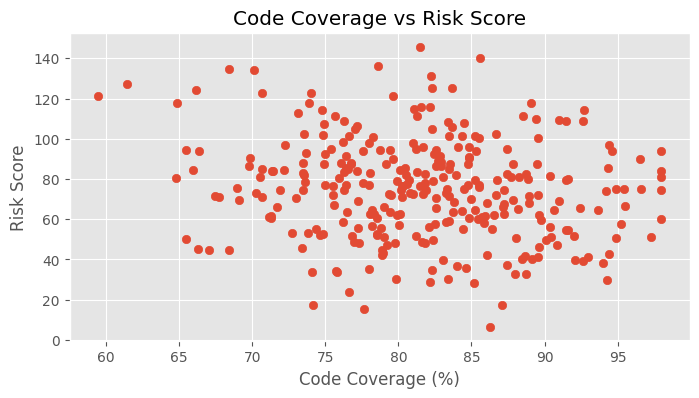

In [256]:
# ==========================================================
# CODE COVERAGE VS RISK SCORE
# ==========================================================

plt.figure(figsize=(8,4))

plt.scatter(

    dashboard_df["code_coverage"],

    dashboard_df["risk_score"]

)

plt.xlabel("Code Coverage (%)")

plt.ylabel("Risk Score")

plt.title("Code Coverage vs Risk Score")

plt.show()

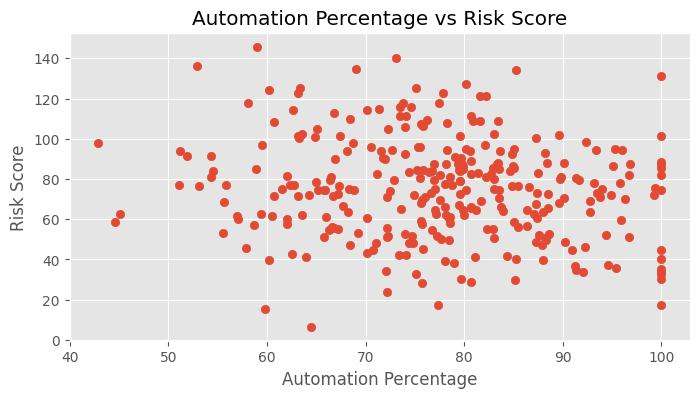

In [257]:
# ==========================================================
# AUTOMATION VS RISK SCORE
# ==========================================================

plt.figure(figsize=(8,4))

plt.scatter(

    dashboard_df["automation_percentage"],

    dashboard_df["risk_score"]

)

plt.xlabel("Automation Percentage")

plt.ylabel("Risk Score")

plt.title("Automation Percentage vs Risk Score")

plt.show()

In [259]:
# ==========================================================
# AI RECOMMENDATION SUMMARY
# ==========================================================

print("="*80)

print("AI RELEASE RECOMMENDATIONS")

print("="*80)

display(

    dashboard_df[

        [

            "release_id",

            "application",

            "release_type",

            "risk_score",

            "release_risk",

            "Predicted_Release_Risk",

            "AI_Recommendation"

        ]

    ]

)

AI RELEASE RECOMMENDATIONS


,release_id,application,release_type,risk_score,release_risk,Predicted_Release_Risk,AI_Recommendation
0,REL00001,Mobile Banking,Major,52.22,Low,Medium,Additional Testing Required
1,REL00002,Internet Banking,Major,77.77,Medium,Medium,Additional Testing Required
2,REL00003,Authentication,Patch,83.81,High,Medium,Additional Testing Required
3,REL00004,CRM,Major,109.95,High,High,Delay Release and Resolve Critical Issues
4,REL00005,Mobile Banking,Hotfix,115.77,High,High,Delay Release and Resolve Critical Issues
...,...,...,...,...,...,...,...
295,REL00296,Cards,Patch,17.19,Low,Low,Ready for Production
296,REL00297,Mobile Banking,Minor,125.47,High,High,Delay Release and Resolve Critical Issues
297,REL00298,Payments,Patch,95.91,High,Medium,Additional Testing Required
298,REL00299,Internet Banking,Hotfix,55.18,Low,Low,Ready for Production


In [261]:
# ==========================================================
# EXECUTIVE SUMMARY
# ==========================================================

print("="*80)

print("AI-DRIVEN TEST ANALYTICS SYSTEM")

print("="*80)

print(f"""
Total Releases Analysed          : {total_releases}

High Risk Releases               : {high}

Medium Risk Releases             : {medium}

Low Risk Releases                : {low}

Average Risk Score               : {avg_risk:.2f}

Overall Pipeline Status          : SUCCESS

AI Recommendation Engine         : ACTIVE

Machine Learning Models Used

1. Random Forest
2. XGBoost
3. XGBoost Pipeline

Final Deliverable

Executive Release Analytics Report Generated Successfully
""")

AI-DRIVEN TEST ANALYTICS SYSTEM

Total Releases Analysed          : 300

High Risk Releases               : 126

Medium Risk Releases             : 104

Low Risk Releases                : 70

Average Risk Score               : 75.00

Overall Pipeline Status          : SUCCESS

AI Recommendation Engine         : ACTIVE

Machine Learning Models Used

1. Random Forest
2. XGBoost
3. XGBoost Pipeline

Final Deliverable

Executive Release Analytics Report Generated Successfully



# **PART 8 – Business Impact Dashboard**

In [263]:
# ==========================================================
# PART 8
# BUSINESS IMPACT DASHBOARD
# ==========================================================

import pandas as pd

dashboard_df = pd.read_csv("final_ai_test_analytics_report.csv")

total_releases = len(dashboard_df)

high = (dashboard_df["Predicted_Release_Risk"]=="High").sum()
medium = (dashboard_df["Predicted_Release_Risk"]=="Medium").sum()
low = (dashboard_df["Predicted_Release_Risk"]=="Low").sum()

release_success_rate = ((low + medium) / total_releases) * 100

deployment_readiness = (100 - dashboard_df["risk_score"].mean())

critical_release_percentage = (high / total_releases) * 100

estimated_testing_hours_saved = (
    dashboard_df["automation_percentage"].mean()/100
) * 200

estimated_defects_prevented = int(
    dashboard_df["failed_tests"].sum()*0.40
)

estimated_cost_saved = estimated_defects_prevented * 2500

In [264]:
print("="*80)
print("EXECUTIVE BUSINESS IMPACT DASHBOARD")
print("="*80)

print(f"Total Releases Analysed          : {total_releases}")

print(f"Low Risk Releases                : {low}")

print(f"Medium Risk Releases             : {medium}")

print(f"High Risk Releases               : {high}")

print("-"*80)

print(f"Release Success Rate             : {release_success_rate:.2f}%")

print(f"Average Release Readiness        : {deployment_readiness:.2f}%")

print(f"Critical Release Percentage      : {critical_release_percentage:.2f}%")

print(f"Estimated Testing Hours Saved    : {estimated_testing_hours_saved:.0f} Hours")

print(f"Estimated Defects Prevented      : {estimated_defects_prevented}")

print(f"Estimated Cost Saving            : ₹{estimated_cost_saved:,.0f}")

print("="*80)

EXECUTIVE BUSINESS IMPACT DASHBOARD
Total Releases Analysed          : 300
Low Risk Releases                : 70
Medium Risk Releases             : 104
High Risk Releases               : 126
--------------------------------------------------------------------------------
Release Success Rate             : 58.00%
Average Release Readiness        : 25.00%
Critical Release Percentage      : 42.00%
Estimated Testing Hours Saved    : 155 Hours
Estimated Defects Prevented      : 5648
Estimated Cost Saving            : ₹14,120,000


In [265]:
print("="*80)

print("BUSINESS RECOMMENDATIONS")

print("="*80)

if high > medium:

    print("Priority 1 : Reduce High Risk Releases")

if deployment_readiness < 75:

    print("Priority 2 : Improve Code Coverage")

if dashboard_df["automation_percentage"].mean() < 80:

    print("Priority 3 : Increase Automation Coverage")

if dashboard_df["rollback_count"].mean() > 2:

    print("Priority 4 : Improve Release Stability")

print("="*80)

BUSINESS RECOMMENDATIONS
Priority 1 : Reduce High Risk Releases
Priority 2 : Improve Code Coverage
Priority 3 : Increase Automation Coverage


In [266]:
!pip install plotly

In [267]:
import plotly.express as px
import plotly.graph_objects as go

dashboard_df = pd.read_csv("final_ai_test_analytics_report.csv")

In [269]:
fig = px.line(

    dashboard_df,

    x="release_id",

    y="risk_score",

    markers=True,

    color="Predicted_Release_Risk",

    title="Release Risk Score"

)

fig.show()

In [270]:
fig = px.scatter(

    dashboard_df,

    x="code_coverage",

    y="automation_percentage",

    color="Predicted_Release_Risk",

    size="risk_score",

    hover_name="release_id",

    title="Code Coverage vs Automation"

)

fig.show()

In [271]:
fig = px.sunburst(

    dashboard_df,

    path=[

        "application",

        "release_type",

        "Predicted_Release_Risk"

    ],

    values="risk_score",

    title="Application Release Risk"

)

fig.show()

In [273]:
fig = go.Figure(

    data=[

        go.Table(

            header=dict(

                values=list(

                    dashboard_df[[
                        "release_id",
                        "application",
                        "Predicted_Release_Risk",
                        "AI_Recommendation"
                    ]].columns
                )
            ),

            cells=dict(

                values=[

                    dashboard_df["release_id"],

                    dashboard_df["application"],

                    dashboard_df["Predicted_Release_Risk"],

                    dashboard_df["AI_Recommendation"]

                ]
            )

        )

    ]

)

fig.show()

In [275]:
dashboard_df["Release_Readiness"] = (

    100 -

    dashboard_df["risk_score"]

).clip(0,100)

dashboard_df["Release_Readiness"] = dashboard_df[
    "Release_Readiness"
].round(2)

print("="*80)

print("EXECUTIVE RELEASE READINESS REPORT")

print("="*80)

print(
    dashboard_df[
        ["release_id", "Release_Readiness"]
    ]
)

display(
    dashboard_df[
        [
            "release_id",
            "risk_score",
            "Release_Readiness",
            "Predicted_Release_Risk",
            "AI_Recommendation"
        ]
    ]
)

EXECUTIVE RELEASE READINESS REPORT
    release_id  Release_Readiness
0     REL00001              47.78
1     REL00002              22.23
2     REL00003              16.19
3     REL00004               0.00
4     REL00005               0.00
..         ...                ...
295   REL00296              82.81
296   REL00297               0.00
297   REL00298               4.09
298   REL00299              44.82
299   REL00300               9.77

[300 rows x 2 columns]


,release_id,risk_score,Release_Readiness,Predicted_Release_Risk,AI_Recommendation
0,REL00001,52.22,47.78,Medium,Additional Testing Required
1,REL00002,77.77,22.23,Medium,Additional Testing Required
2,REL00003,83.81,16.19,Medium,Additional Testing Required
3,REL00004,109.95,0.00,High,Delay Release and Resolve Critical Issues
4,REL00005,115.77,0.00,High,Delay Release and Resolve Critical Issues
...,...,...,...,...,...
295,REL00296,17.19,82.81,Low,Ready for Production
296,REL00297,125.47,0.00,High,Delay Release and Resolve Critical Issues
297,REL00298,95.91,4.09,Medium,Additional Testing Required
298,REL00299,55.18,44.82,Low,Ready for Production
